<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Drug_Labels_%26_Side_Effects_Dataset_%7C_1400%2B_Records_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d pratyushpuri/drug-labels-and-side-effects-dataset-1400-records

# Unziping the downloaded file
!unzip drug-labels-and-side-effects-dataset-1400-records.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/pratyushpuri/drug-labels-and-side-effects-dataset-1400-records
License(s): apache-2.0
  0% 0.00/50.7k [00:00<?, ?B/s]
100% 50.7k/50.7k [00:00<00:00, 182MB/s]
Archive:  drug-labels-and-side-effects-dataset-1400-records.zip
  inflating: realistic_drug_labels_side_effects.csv  


In [5]:
df = pd.read_csv('realistic_drug_labels_side_effects.csv')
df.head(11)

,drug_name,manufacturer,approval_year,drug_class,indications,side_effects,dosage_mg,administration_route,contraindications,warnings,price_usd,batch_number,expiry_date,side_effect_severity,approval_status
0,Seroxetine50,AstraZeneca,1996,Antidepressant,Allergy relief,"Fatigue, Nausea",260,Rectal,Bleeding disorders,Avoid alcohol,192.43,MV388Pl,2026-11-29,Mild,Pending
1,Mecoparin93,AstraZeneca,2018,Vaccine,Allergy relief,Nausea,470,Inhalation,Allergic reaction,Take with food,397.82,UR279ZN,2027-07-14,Mild,Approved
2,Daxozole89,Merck & Co.,1997,Antipsychotic,Allergy relief,"Diarrhea, Blurred vision, Dizziness",330,Sublingual,High blood pressure,Take with food,131.69,we040kH,2028-06-02,Moderate,Pending
3,Viracillin84,Roche Holding AG,2004,Antifungal,Inflammation reduction,"Fatigue, Dry mouth",450,Oral,Kidney impairment,Do not operate machinery,372.82,hO060rh,2026-07-07,Mild,Rejected
4,Amoxstatin62,Pfizer Inc.,2003,Antidepressant,Psychosis control,"Insomnia, Dry mouth, Fatigue",430,Topical,Bleeding disorders,Do not operate machinery,281.48,Fa621Sw,2027-12-28,Moderate,Pending
5,Loxocillin72,Johnson & Johnson,2023,Antifungal,Viral infections,"Rash, Dizziness",180,Intravenous,Bleeding disorders,May affect fertility,463.28,Nl465Ez,2025-12-15,Moderate,Rejected
6,Fenoxetine43,AstraZeneca,2004,Anti-inflammatory,Psychosis control,Blurred vision,500,Topical,Bleeding disorders,May affect fertility,320.77,Id480PC,2025-10-24,Mild,Pending
7,Fenomab17,GlaxoSmithKline,2018,Analgesic,Bacterial infections,Nausea,570,Inhalation,Seizures,Avoid alcohol,57.48,XK920cq,2026-09-27,Severe,Approved
8,Cefparin42,Sanofi,2012,Analgesic,Prevent infectious disease,Dry mouth,420,Oral,Asthma,Avoid alcohol,251.97,TU342KC,2026-10-04,Moderate,Approved
9,Rivaprofen81,GlaxoSmithKline,2013,Antibiotic,Bacterial infections,"Insomnia, Fatigue, Headache",580,Intramuscular,Pregnancy,Take with food,4.48,LQ578uz,2025-10-25,Severe,Approved


In [6]:
df.tail(11)

,drug_name,manufacturer,approval_year,drug_class,indications,side_effects,dosage_mg,administration_route,contraindications,warnings,price_usd,batch_number,expiry_date,side_effect_severity,approval_status
1425,Mecostatin50,Roche Holding AG,1999,Antidepressant,Psychosis control,Insomnia,240,Topical,Diabetes,Avoid alcohol,177.90,vM772mm,2026-07-12,Moderate,Rejected
1426,Serostatin23,Merck & Co.,2017,Antipsychotic,Pain relief,"Blurred vision, Diarrhea, Constipation",530,Oral,Seizures,May cause drowsiness,377.17,PI835ml,2026-03-22,Moderate,Pending
1427,Daxovir95,Novartis AG,2019,Antihistamine,Pain relief,Rash,280,Rectal,Liver disease,Monitor blood pressure,444.13,bf284kJ,2026-11-18,Moderate,Pending
1428,Fenoprofen19,Bayer AG,2024,Antipyretic,Prevent infectious disease,"Headache, Blurred vision",190,Intramuscular,Kidney impairment,May affect fertility,8.40,nJ564uk,2026-02-09,Severe,Rejected
1429,Zyloprofen28,Merck & Co.,1998,Antihistamine,Prevent infectious disease,Diarrhea,970,Intramuscular,Liver disease,May cause drowsiness,433.78,AV883is,2027-04-25,Mild,Rejected
1430,Zylostatin67,Bayer AG,2023,Anti-inflammatory,Pain relief,Insomnia,900,Inhalation,Bleeding disorders,Use with caution in elderly,234.35,BU934ws,2025-10-02,Severe,Pending
1431,Mecozole92,Pfizer Inc.,1993,Antihistamine,Fungal infections,Dry mouth,850,Inhalation,Liver disease,May affect fertility,47.48,Kv961uR,2026-01-20,Moderate,Rejected
1432,Amoxvir17,GlaxoSmithKline,2010,Antihistamine,Fungal infections,"Nausea, Fatigue, Headache",880,Inhalation,Diabetes,May affect fertility,235.37,Uc964RO,2027-09-28,Severe,Rejected
1433,Zylovir17,Pfizer Inc.,2007,Antibiotic,Fever reduction,"Insomnia, Dizziness",960,Topical,Asthma,Do not operate machinery,145.09,Fq361YH,2026-02-08,Moderate,Rejected
1434,Mecoprofen32,GlaxoSmithKline,1994,Antifungal,Bacterial infections,Headache,670,Topical,Asthma,May cause drowsiness,263.19,qM405ML,2028-05-13,Severe,Pending


In [7]:
df.shape

(1436, 15)

In [8]:
df.columns

Index(['drug_name', 'manufacturer', 'approval_year', 'drug_class',
       'indications', 'side_effects', 'dosage_mg', 'administration_route',
       'contraindications', 'warnings', 'price_usd', 'batch_number',
       'expiry_date', 'side_effect_severity', 'approval_status'],
      dtype='object')

In [9]:
df.dtypes

,0
drug_name,object
manufacturer,object
approval_year,int64
drug_class,object
indications,object
side_effects,object
dosage_mg,int64
administration_route,object
contraindications,object
warnings,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   drug_name             1436 non-null   object 
 1   manufacturer          1436 non-null   object 
 2   approval_year         1436 non-null   int64  
 3   drug_class            1436 non-null   object 
 4   indications           1436 non-null   object 
 5   side_effects          1436 non-null   object 
 6   dosage_mg             1436 non-null   int64  
 7   administration_route  1436 non-null   object 
 8   contraindications     1436 non-null   object 
 9   warnings              1436 non-null   object 
 10  price_usd             1436 non-null   float64
 11  batch_number          1436 non-null   object 
 12  expiry_date           1436 non-null   object 
 13  side_effect_severity  1436 non-null   object 
 14  approval_status       1436 non-null   object 
dtypes: float64(1), int64(

In [11]:
df.describe(include = 'all')

,drug_name,manufacturer,approval_year,drug_class,indications,side_effects,dosage_mg,administration_route,contraindications,warnings,price_usd,batch_number,expiry_date,side_effect_severity,approval_status
count,1436,1436,1436.000000,1436,1436,1436,1436.000000,1436,1436,1436,1436.000000,1436,1436,1436,1436
unique,1337,10,NaN,10,10,435,NaN,7,10,10,NaN,1436,806,3,3
top,Viraparin98,Merck & Co.,NaN,Anti-inflammatory,Depression treatment,Blurred vision,NaN,Intramuscular,Asthma,May cause drowsiness,NaN,Ao408CX,2028-06-02,Mild,Pending
freq,4,157,NaN,158,154,63,NaN,233,175,173,NaN,1,7,490,496
mean,NaN,NaN,2006.860028,NaN,NaN,NaN,509.637883,NaN,NaN,NaN,251.844854,NaN,NaN,NaN,NaN
std,NaN,NaN,10.167067,NaN,NaN,NaN,286.417268,NaN,NaN,NaN,142.640781,NaN,NaN,NaN,NaN
min,NaN,NaN,1990.000000,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,1.210000,NaN,NaN,NaN,NaN
25%,NaN,NaN,1998.000000,NaN,NaN,NaN,270.000000,NaN,NaN,NaN,128.830000,NaN,NaN,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,NaN,NaN,515.000000,NaN,NaN,NaN,255.130000,NaN,NaN,NaN,NaN
75%,NaN,NaN,2016.000000,NaN,NaN,NaN,760.000000,NaN,NaN,NaN,372.207500,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
drug_name,0
manufacturer,0
approval_year,0
drug_class,0
indications,0
side_effects,0
dosage_mg,0
administration_route,0
contraindications,0
warnings,0


In [13]:
df.duplicated().sum()

np.int64(0)

# Hanlding Outliers

In [15]:
Q1 = df['price_usd'].quantile(0.25)
Q3 = df['price_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = df[(df['price_usd'] >= lower_bound) | (df['price_usd'] <= upper_bound)].copy()

print(f'Original Shape: {len(df)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 1436
Shape after outlier handling: 1436


# Univariate Analysis

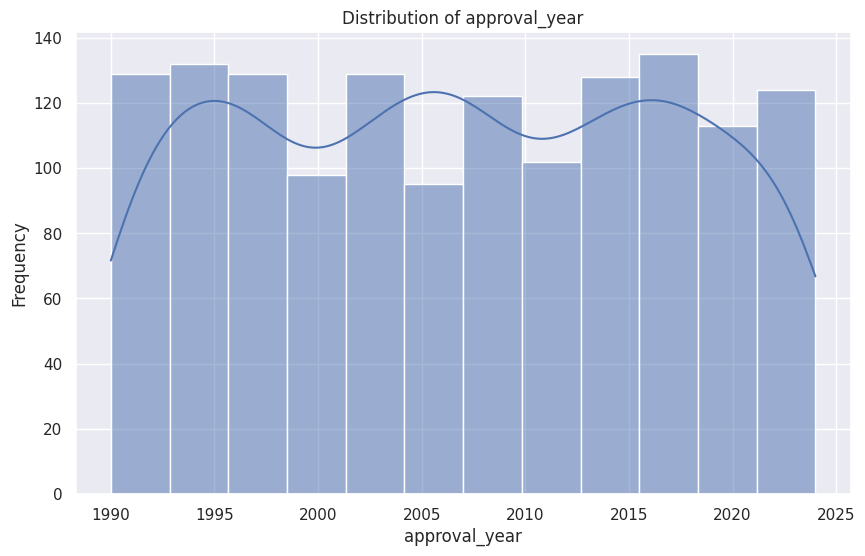

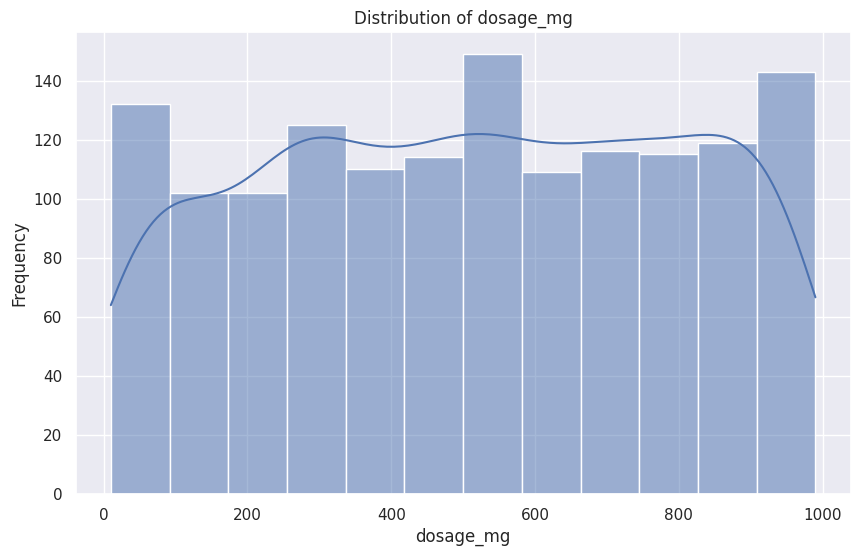

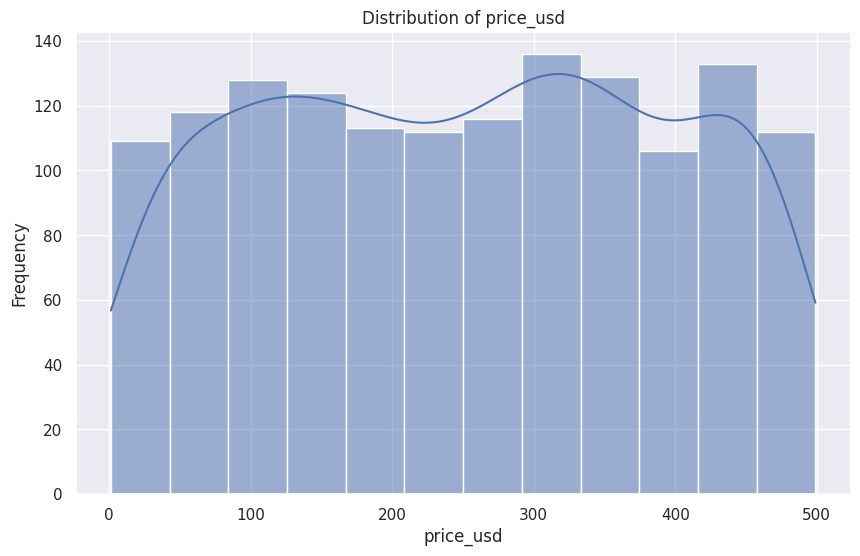

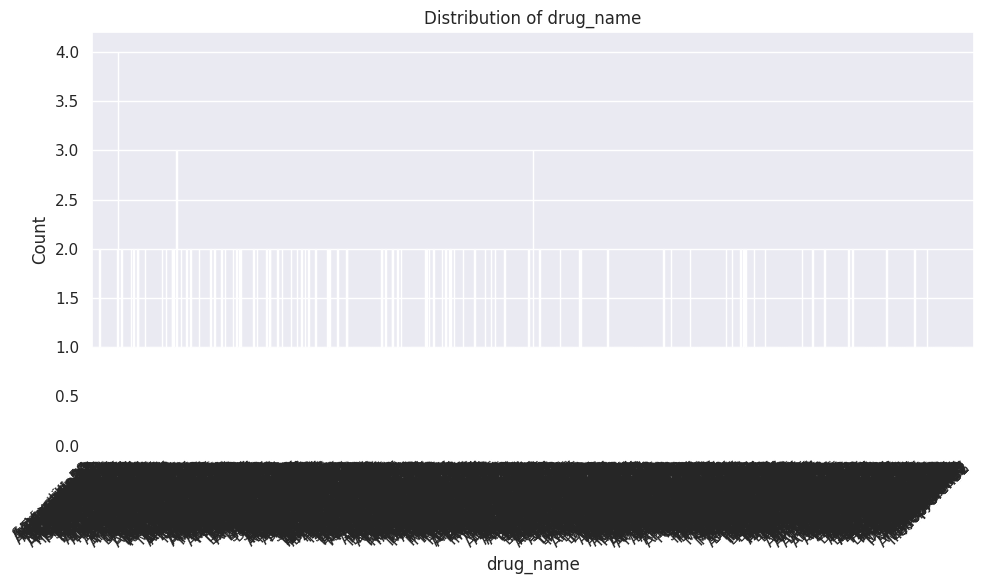

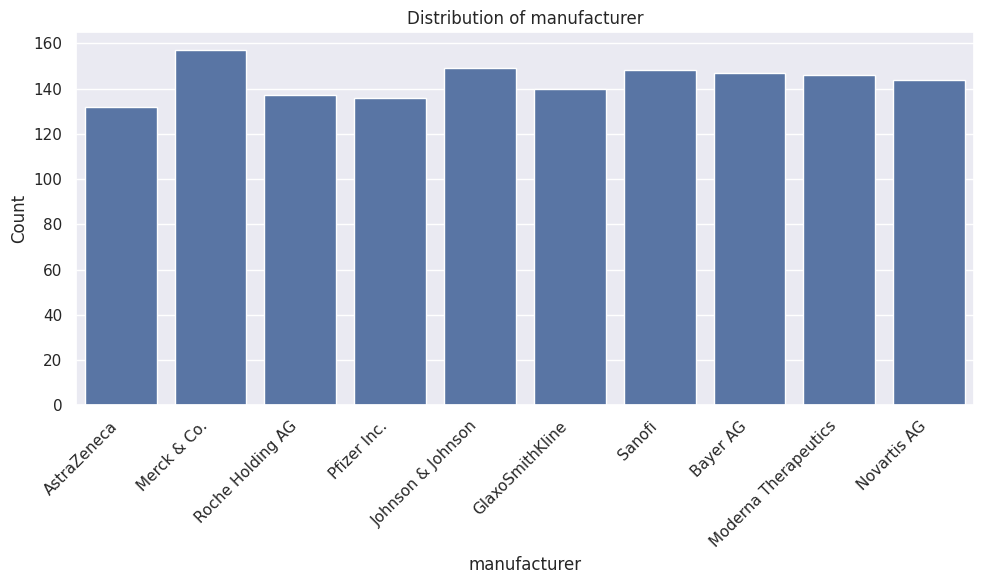

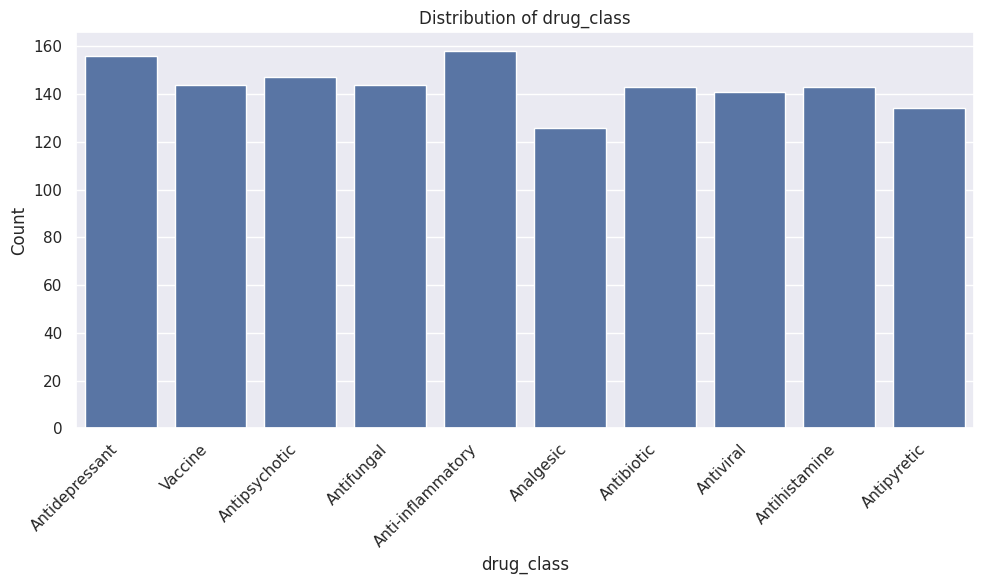

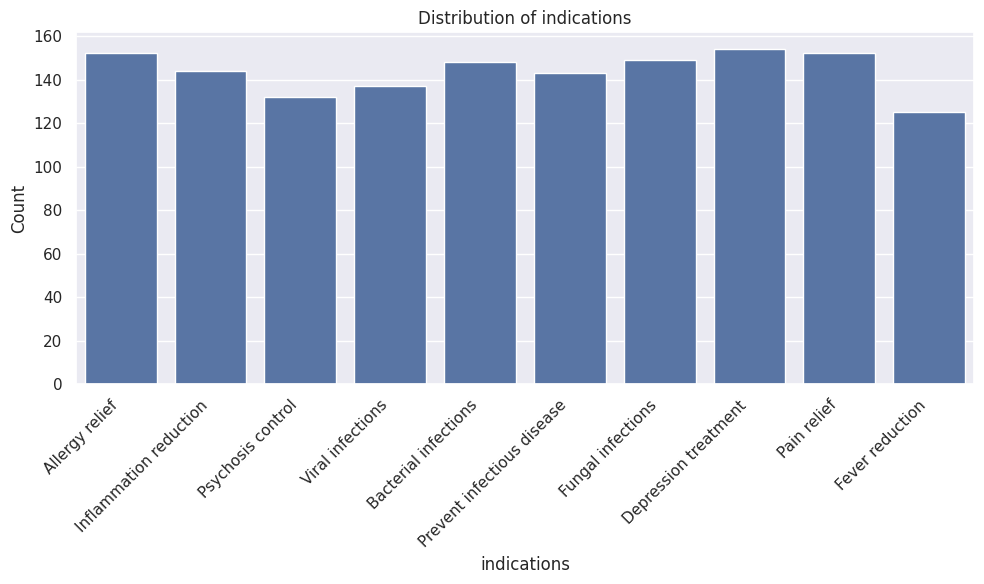

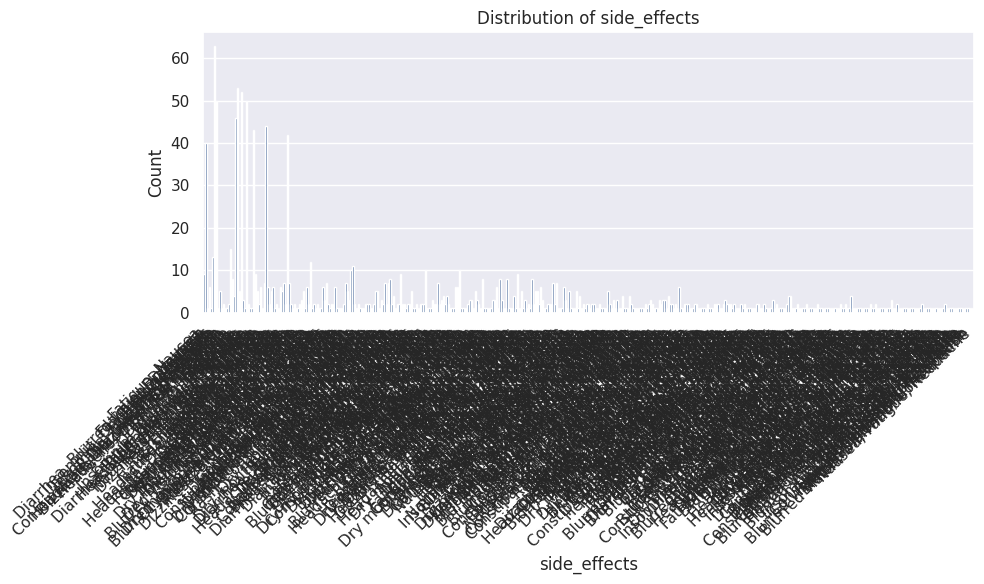

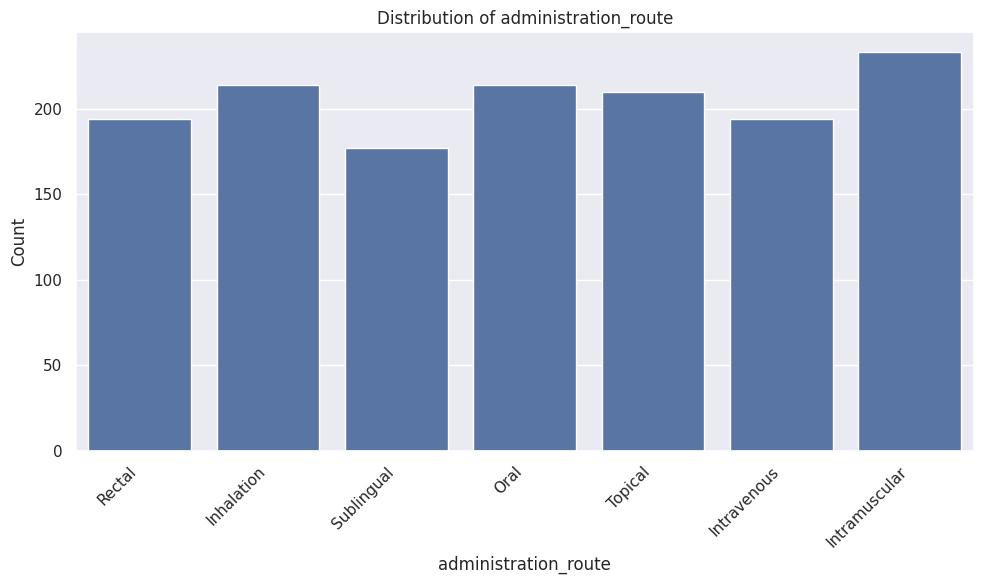

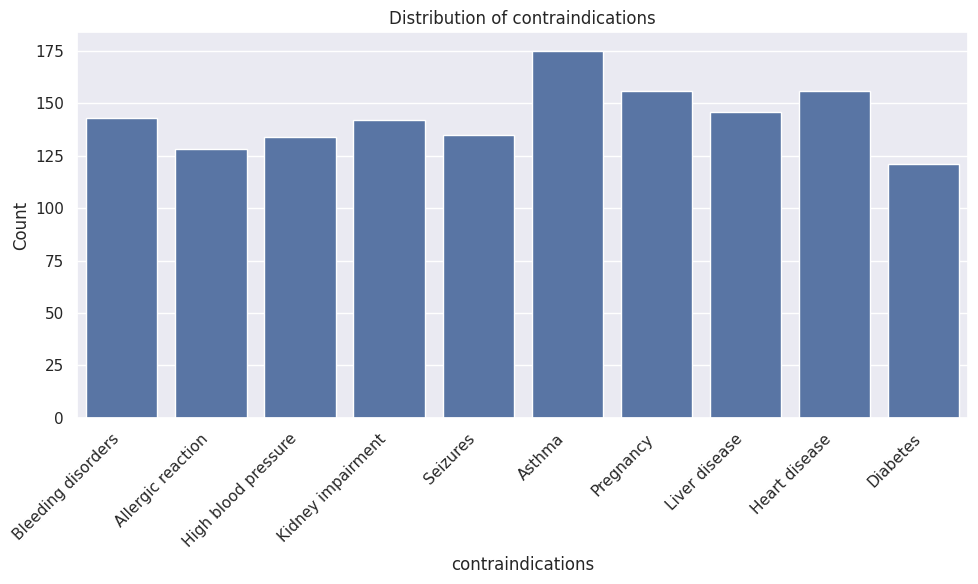

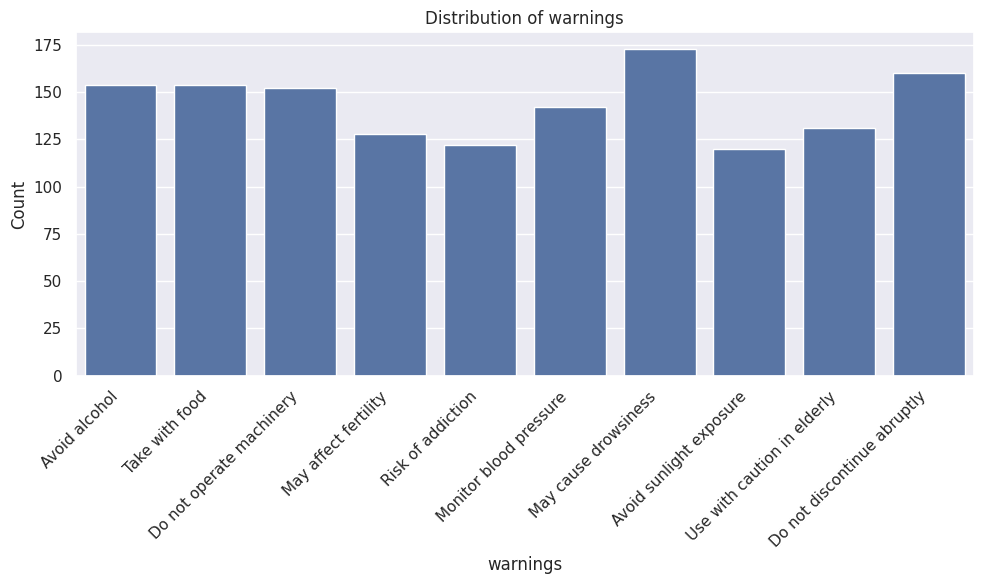

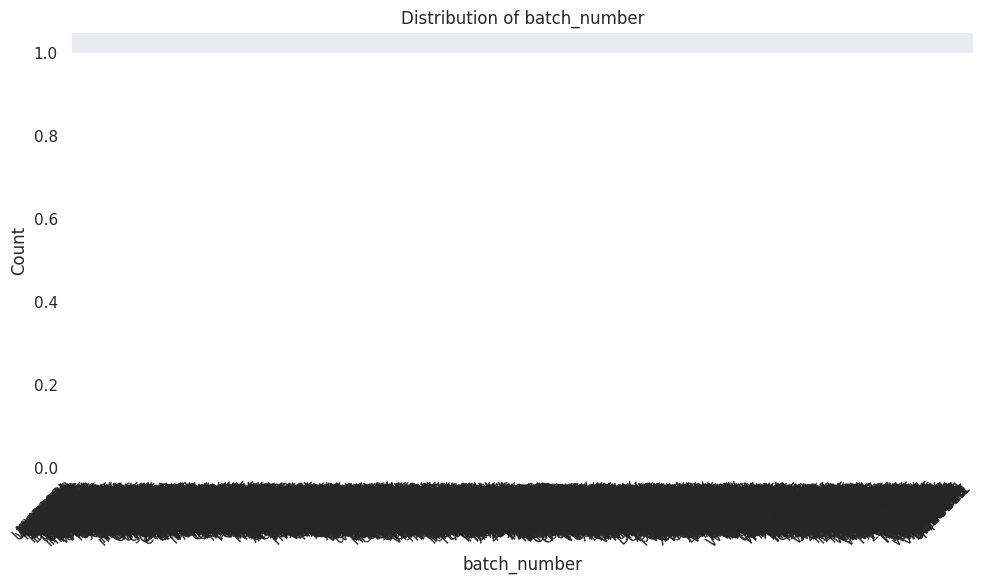

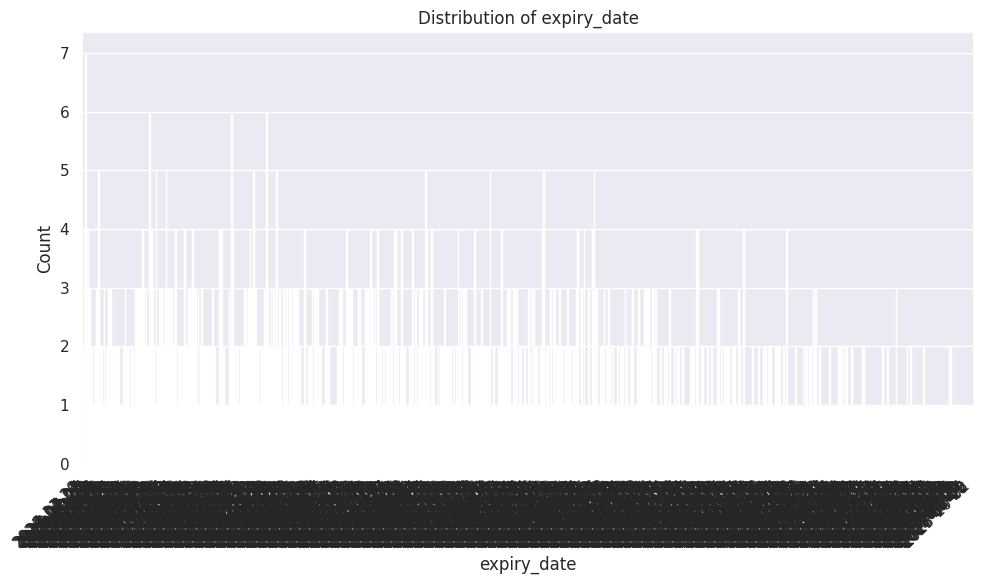

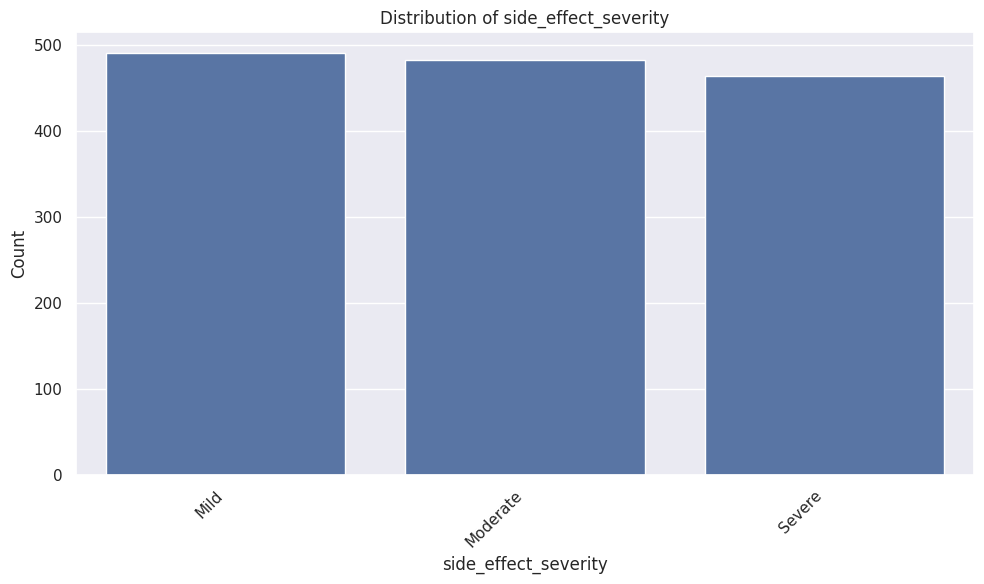

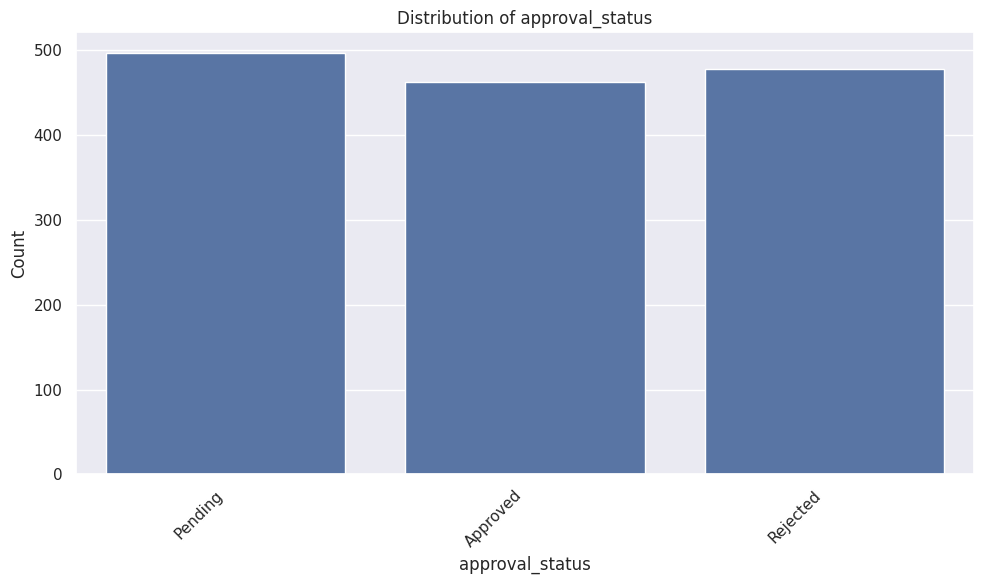

Value counts for drug_name:
drug_name
Viraparin98     4
Viravir99       3
Mecoprofen57    3
Loxostatin36    2
Viraprofen97    2
               ..
Viramab63       1
Fenoxetine28    1
Viraprofen92    1
Daxoxetine26    1
Serozepam96     1
Name: count, Length: 1337, dtype: int64

Value counts for manufacturer:
manufacturer
Merck & Co.             157
Johnson & Johnson       149
Sanofi                  148
Bayer AG                147
Moderna Therapeutics    146
Novartis AG             144
GlaxoSmithKline         140
Roche Holding AG        137
Pfizer Inc.             136
AstraZeneca             132
Name: count, dtype: int64

Value counts for drug_class:
drug_class
Anti-inflammatory    158
Antidepressant       156
Antipsychotic        147
Vaccine              144
Antifungal           144
Antibiotic           143
Antihistamine        143
Antiviral            141
Antipyretic          134
Analgesic            126
Name: count, dtype: int64

Value counts for indications:
indications
Depression tr

In [16]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

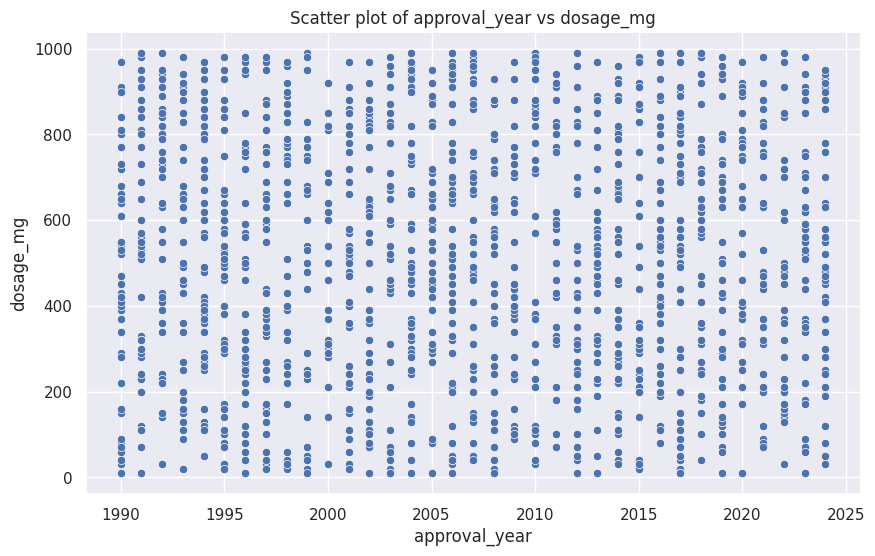

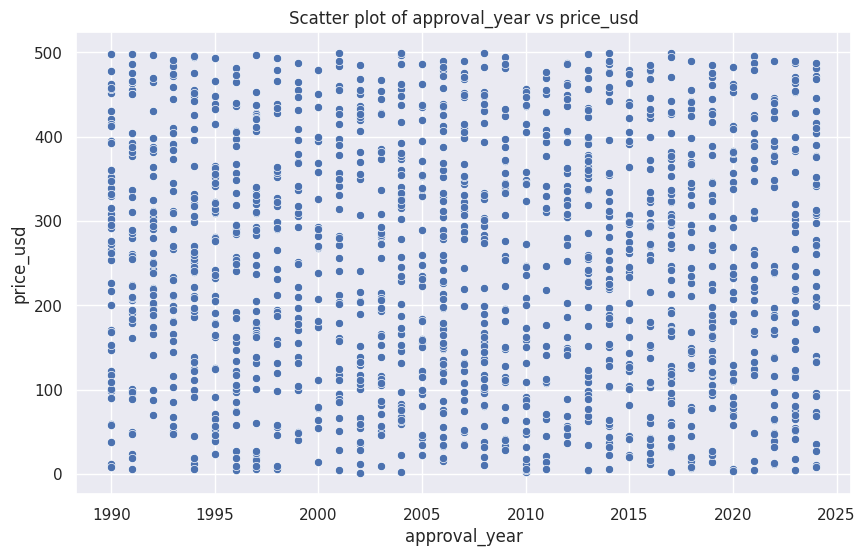

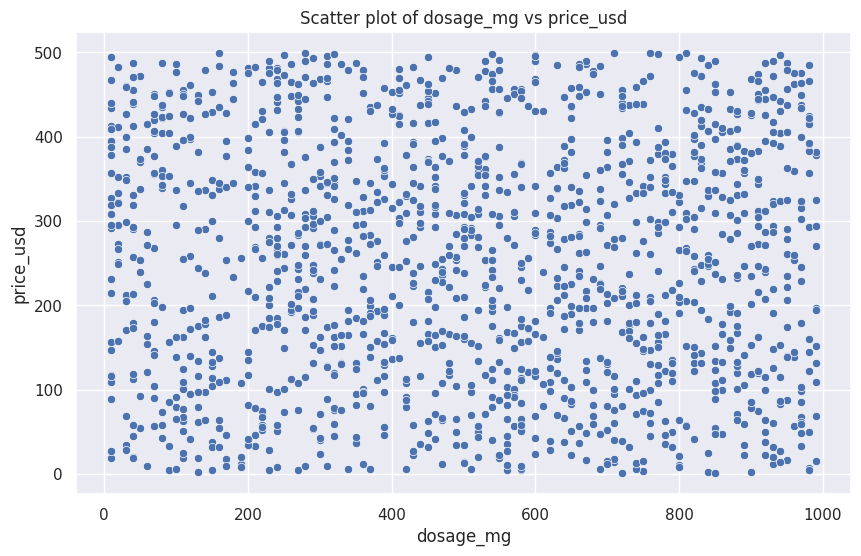

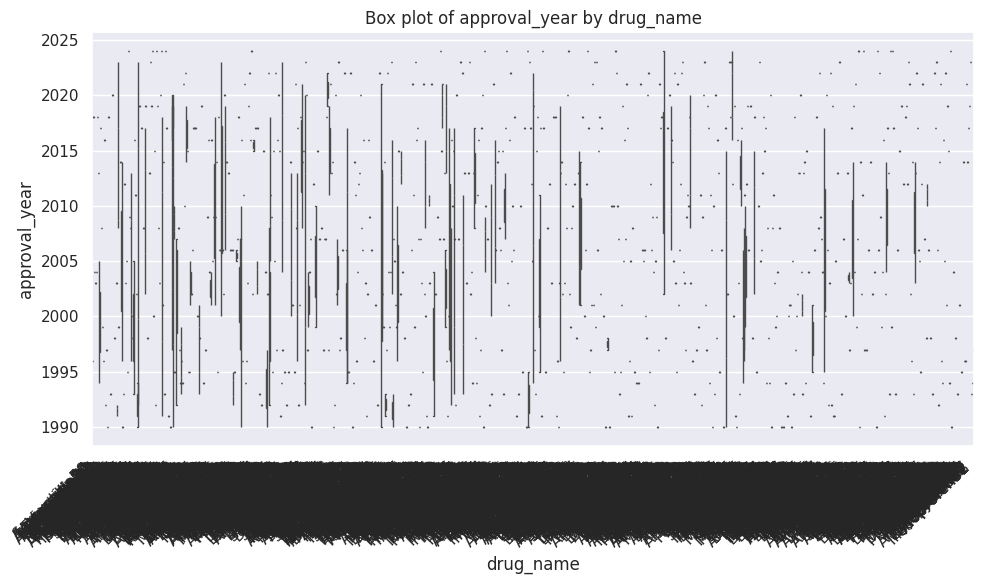

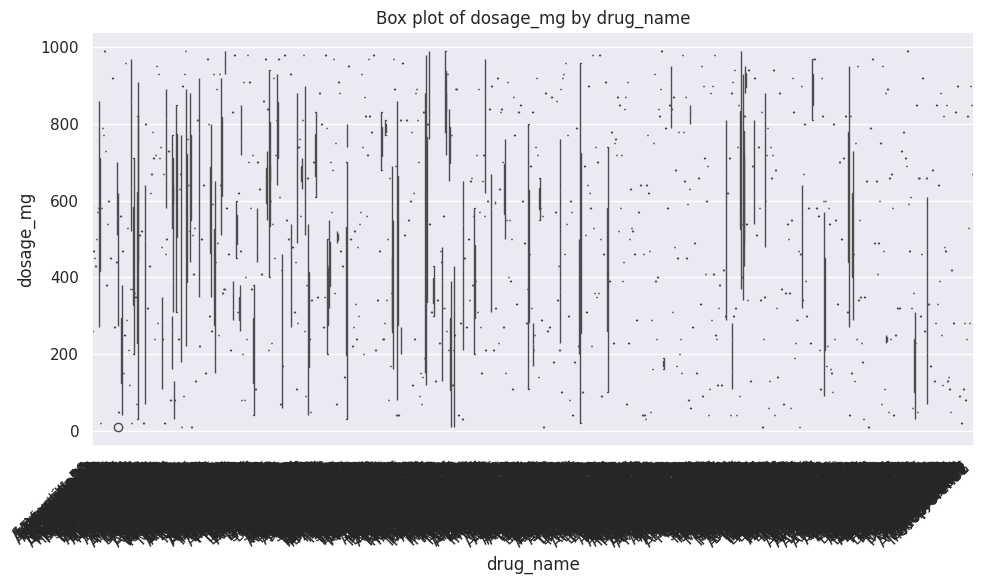

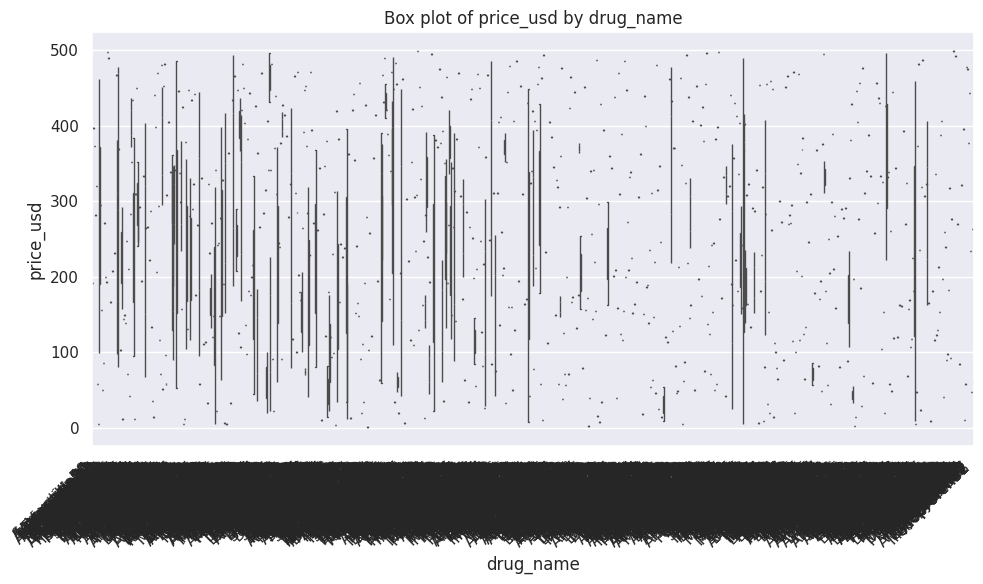

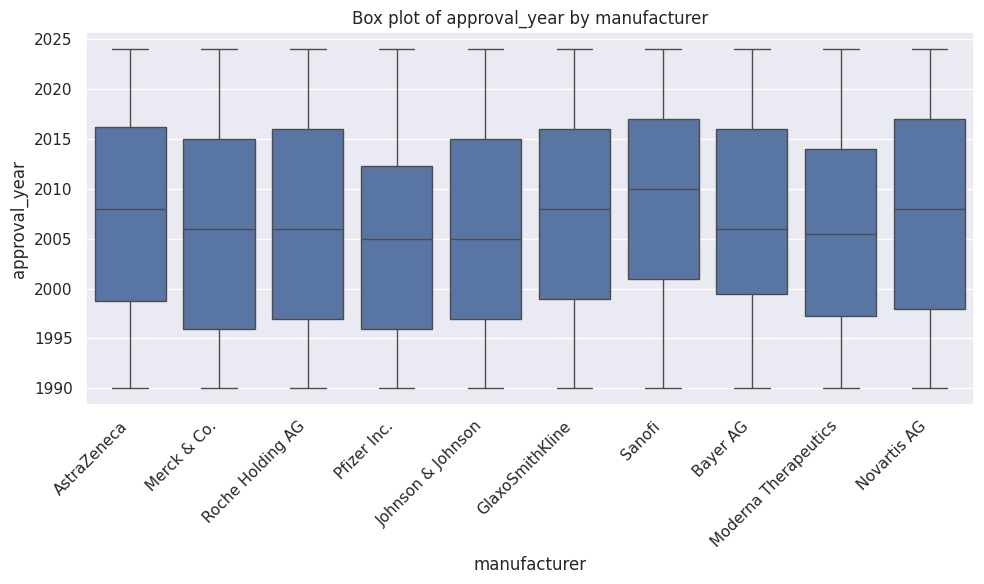

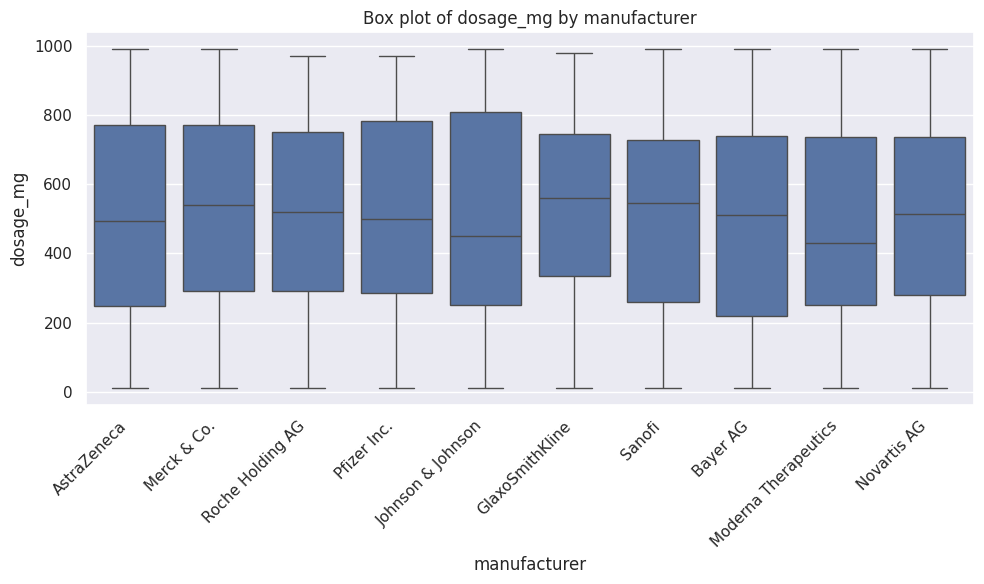

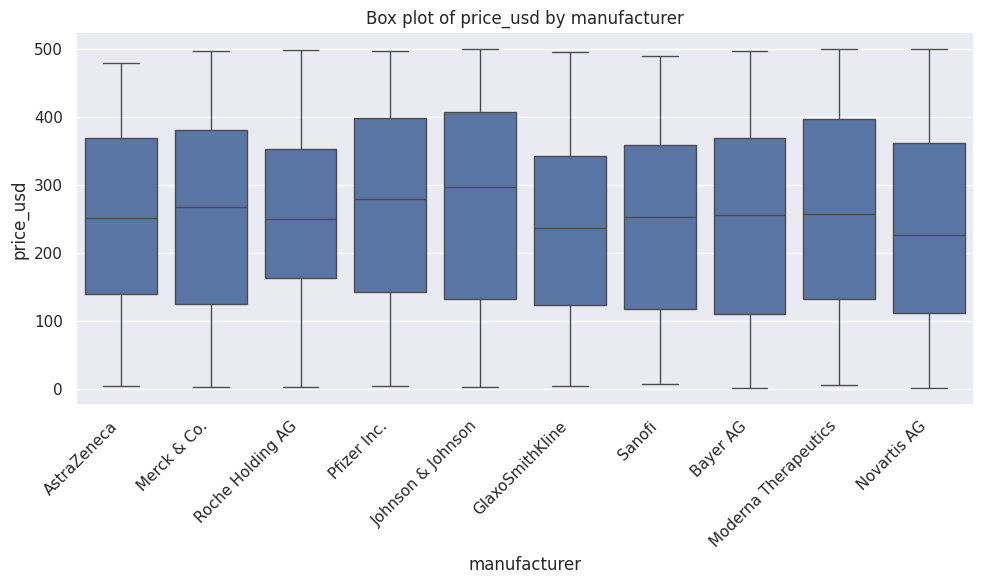

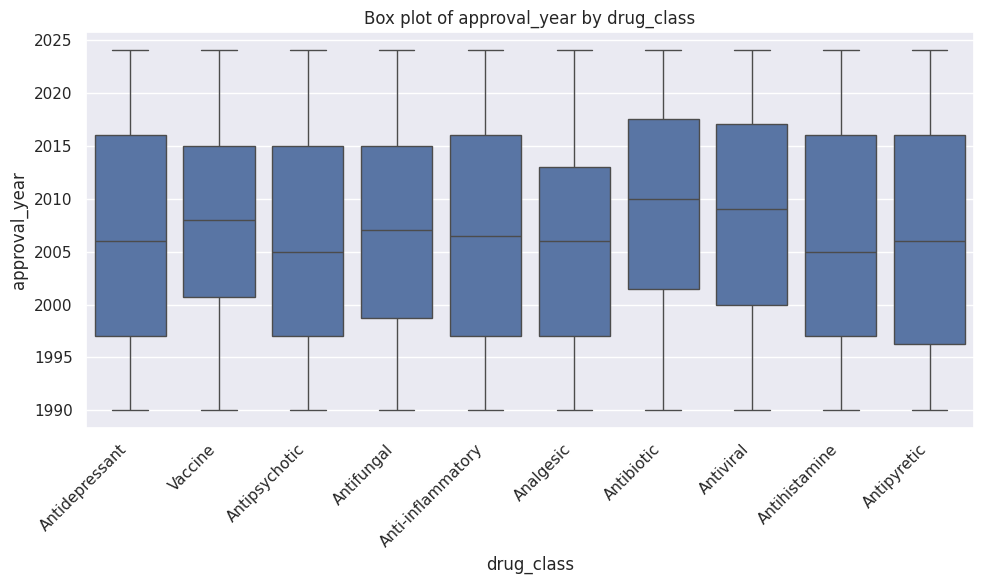

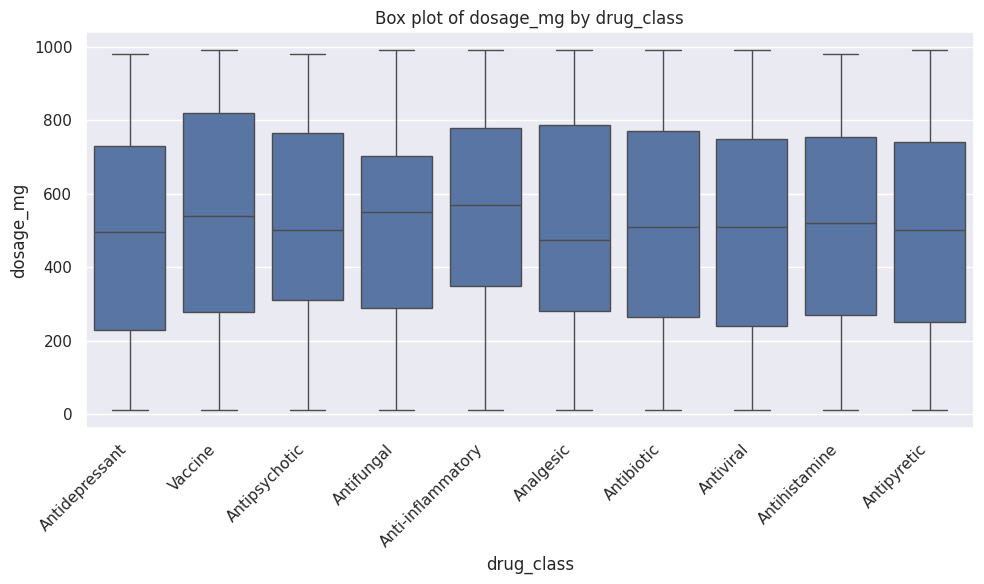

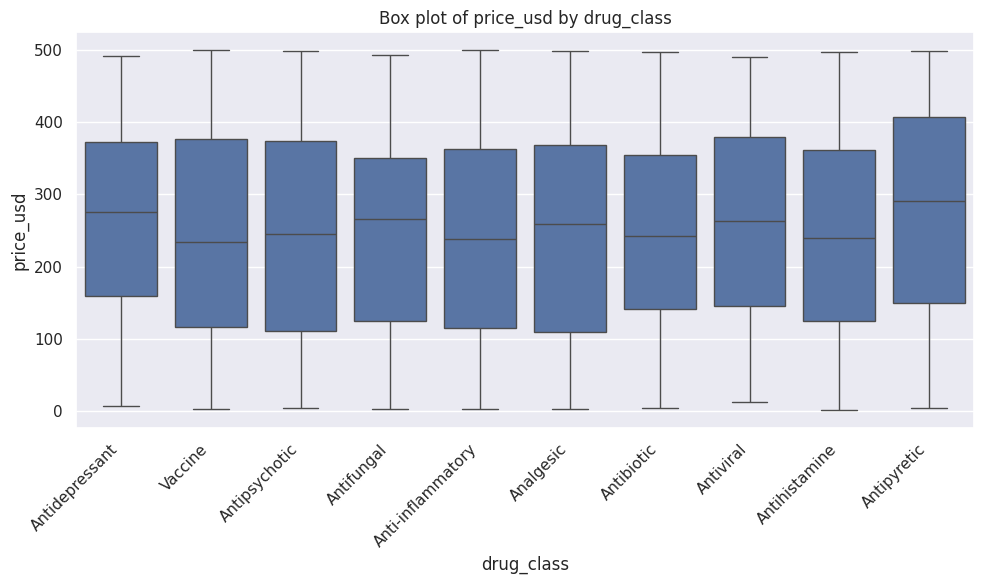

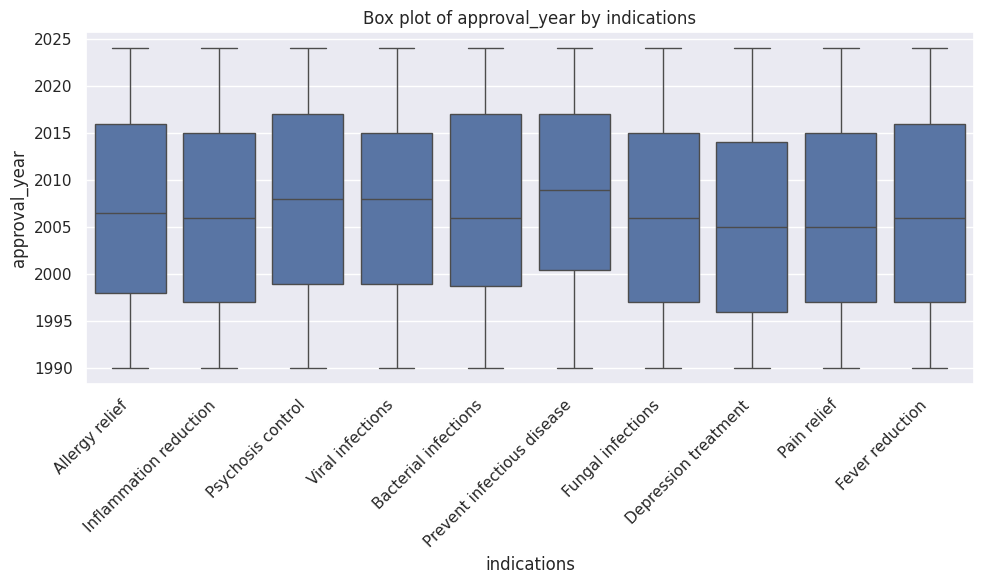

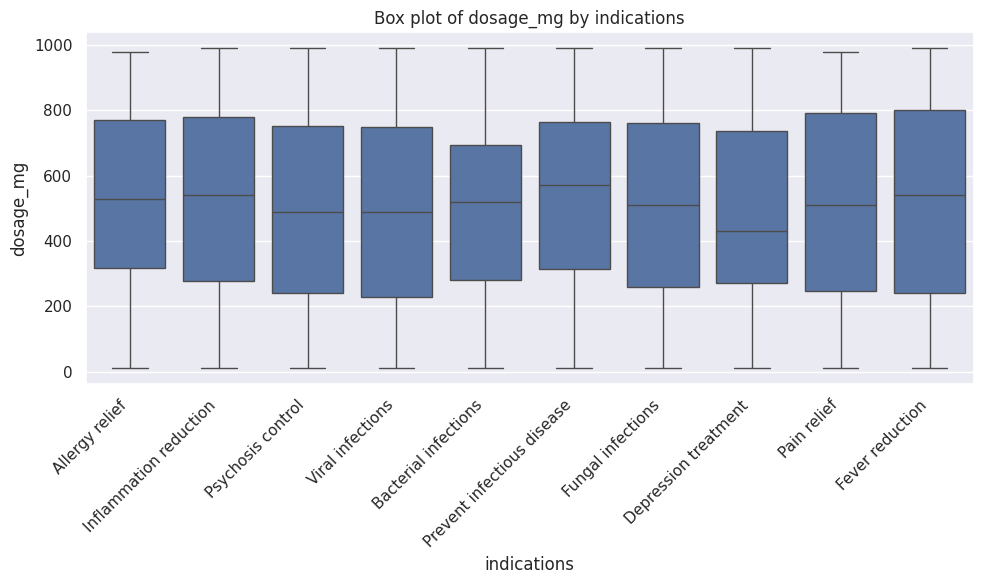

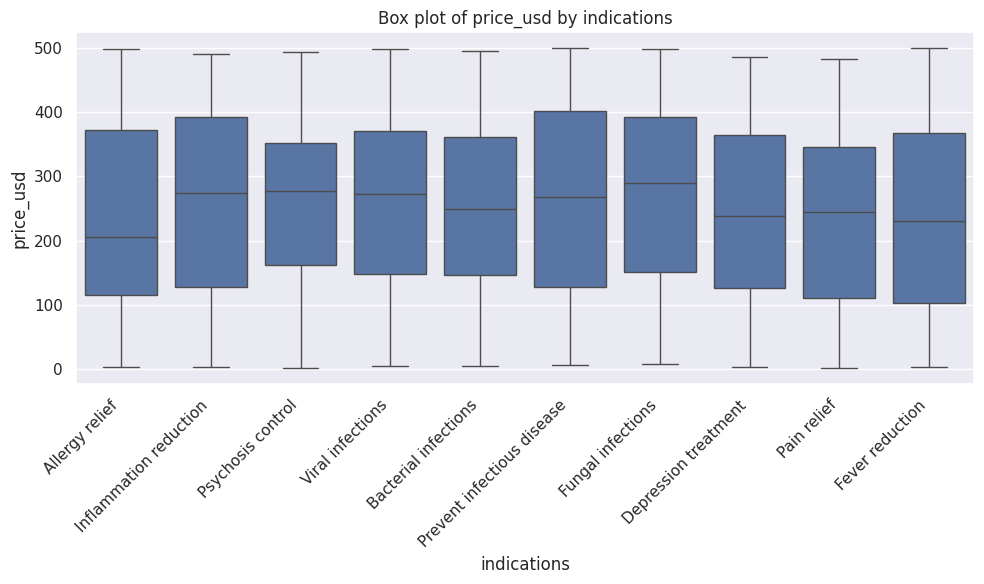

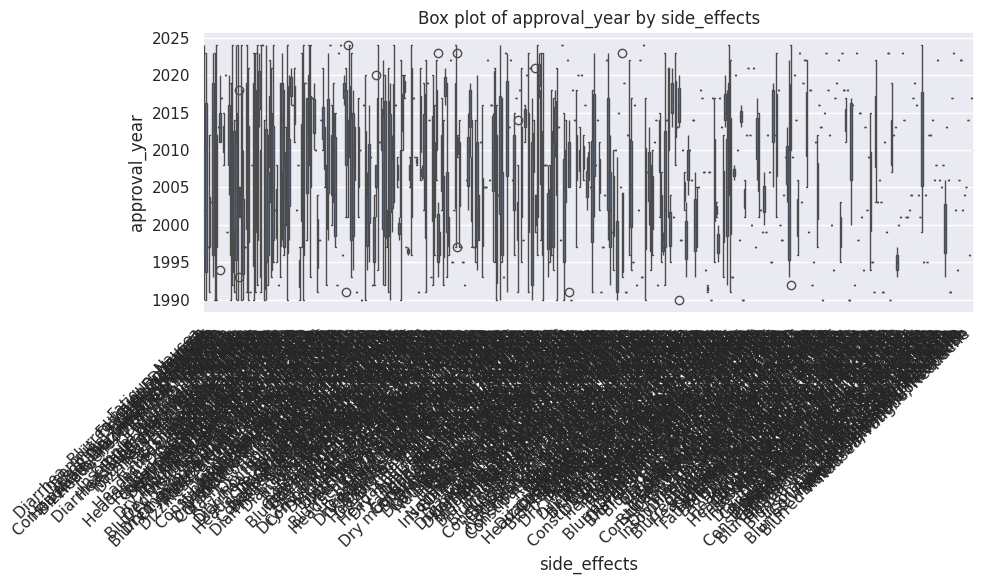

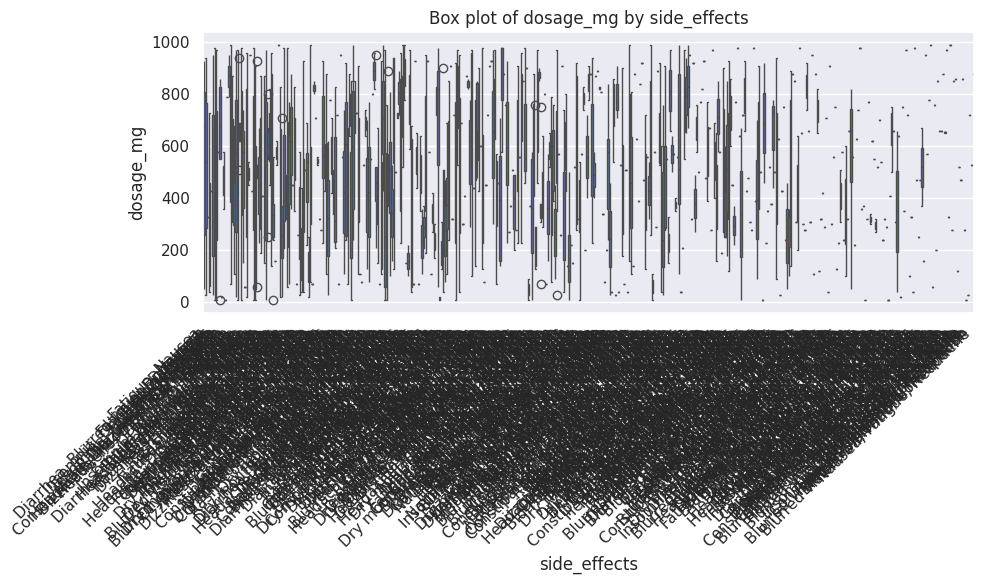

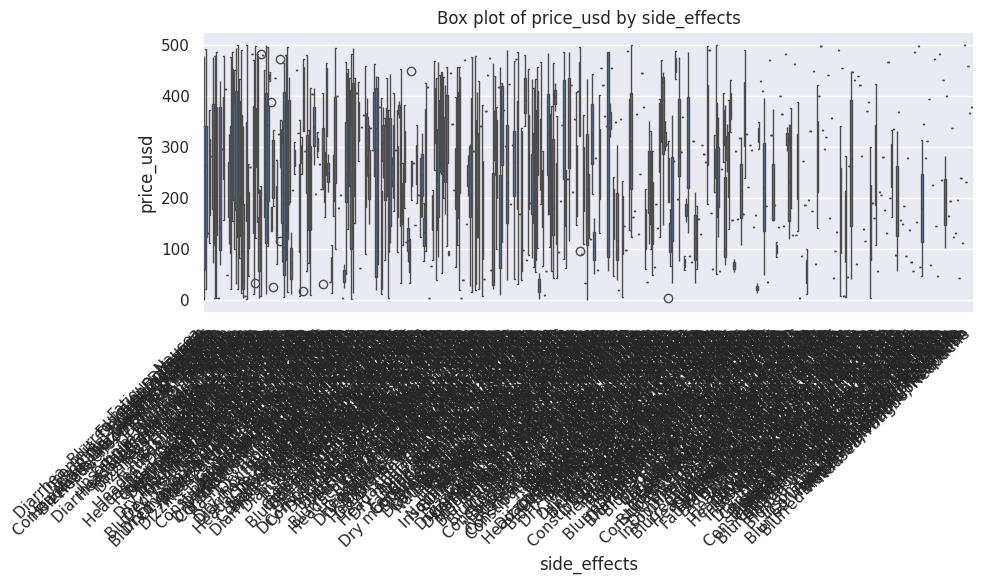

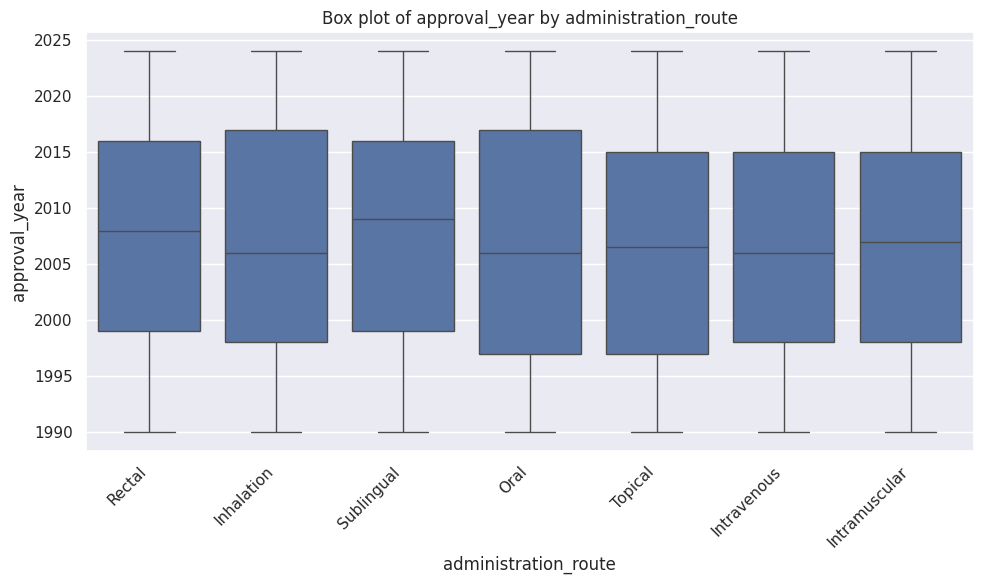

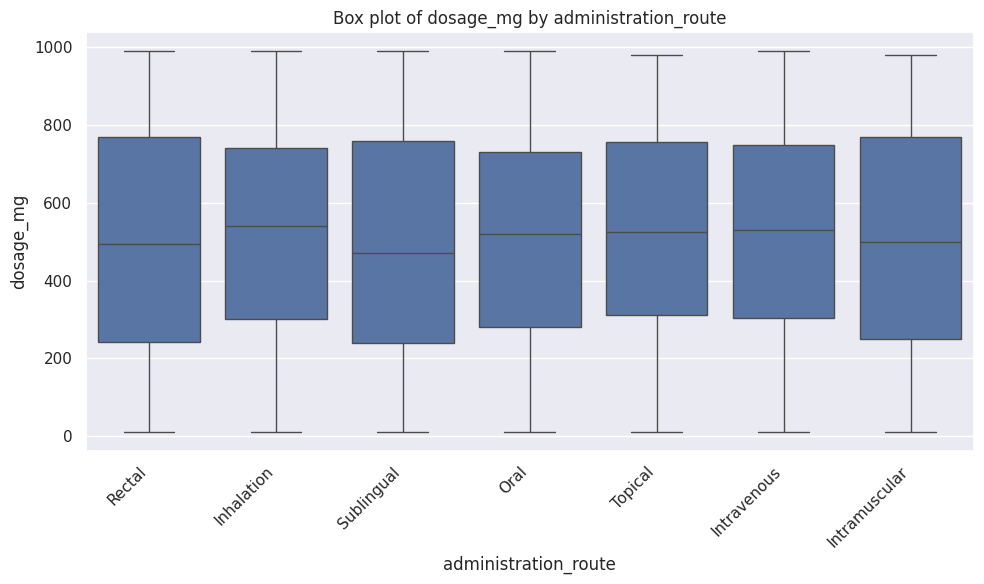

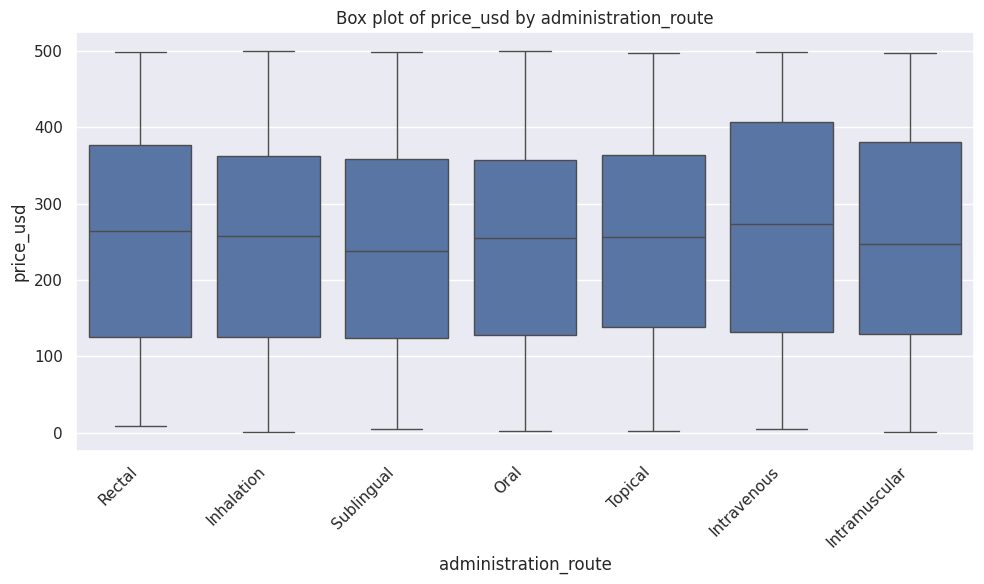

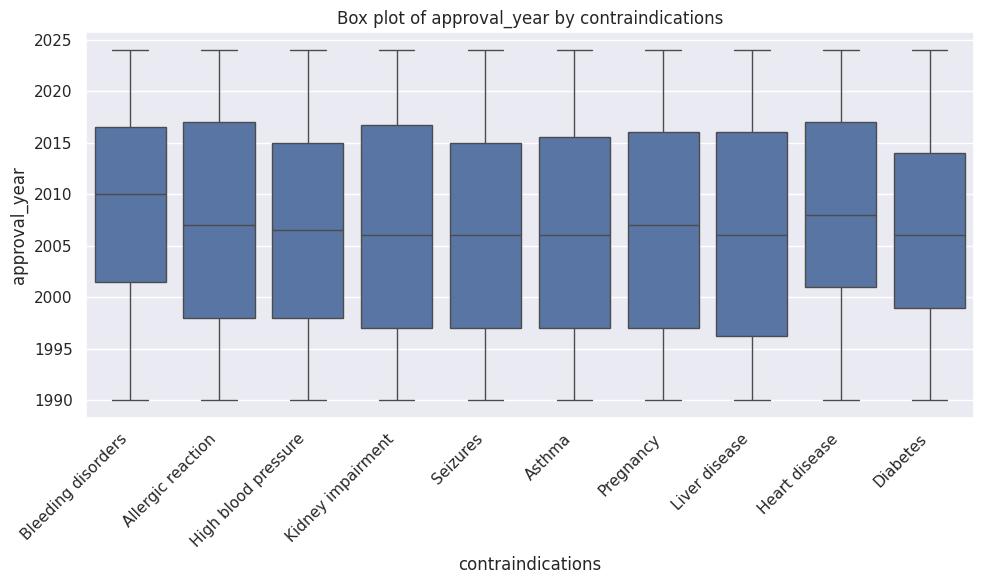

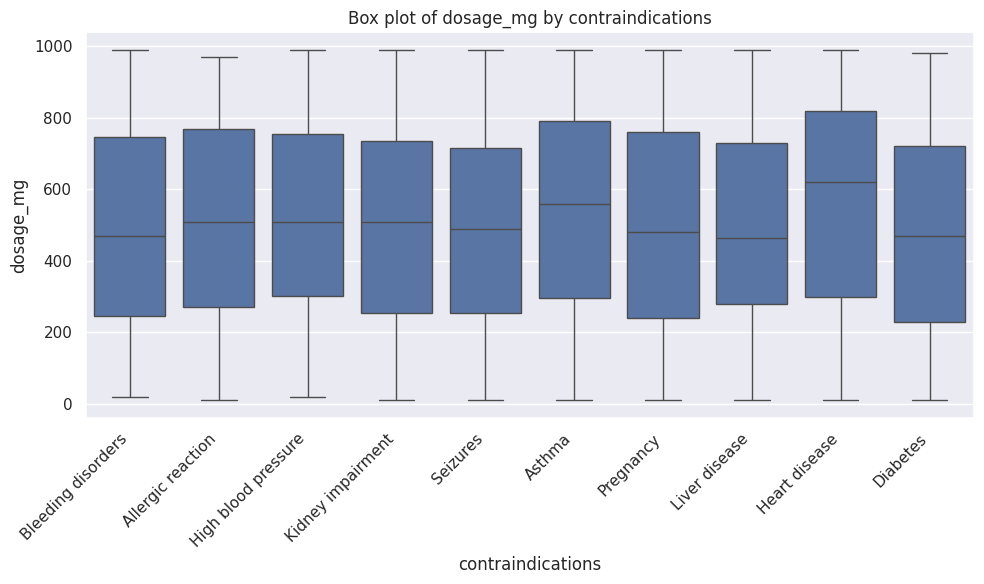

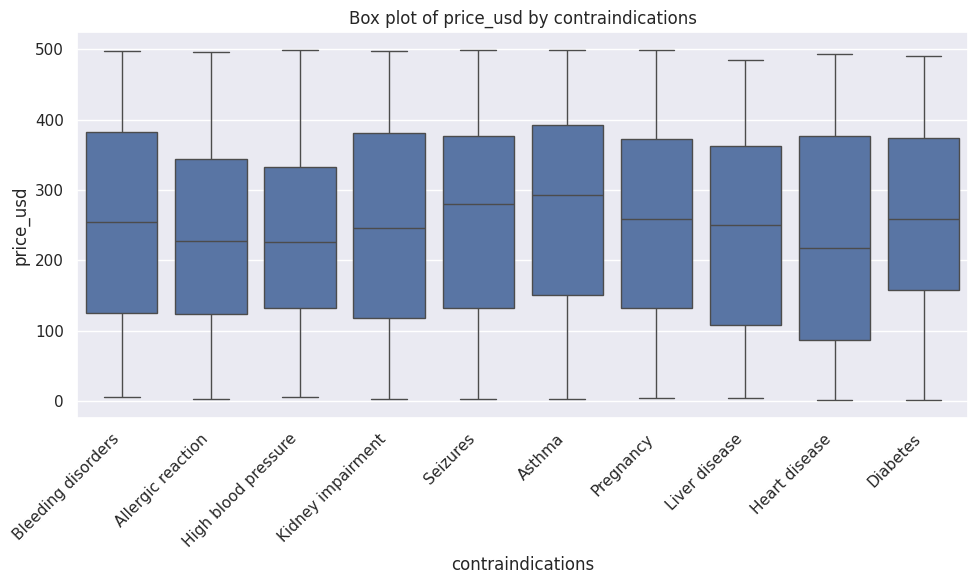

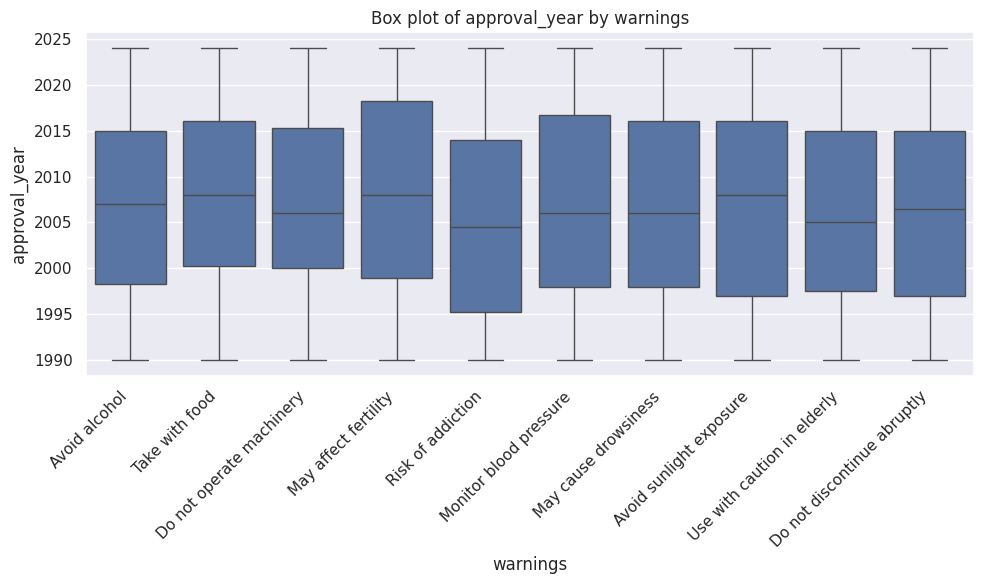

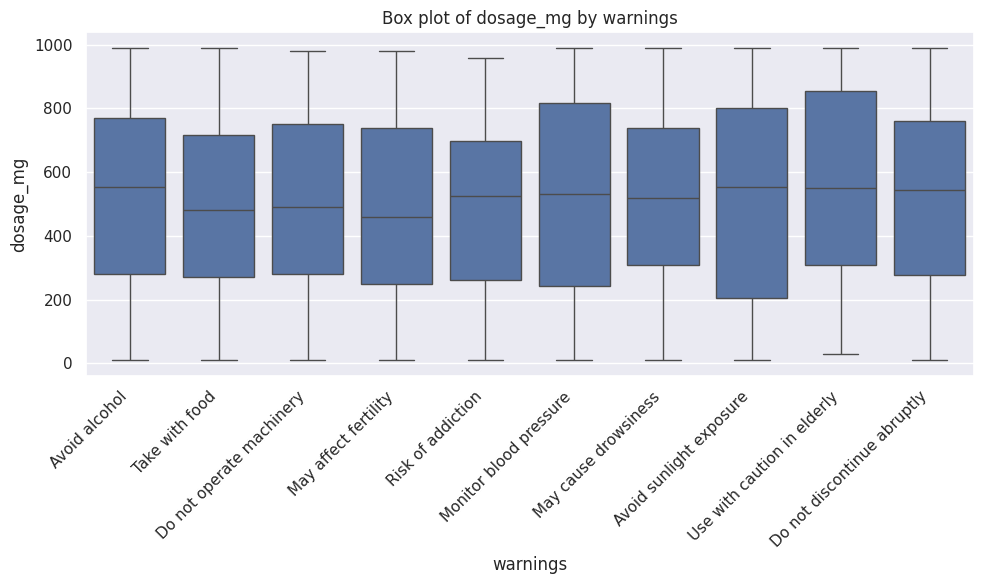

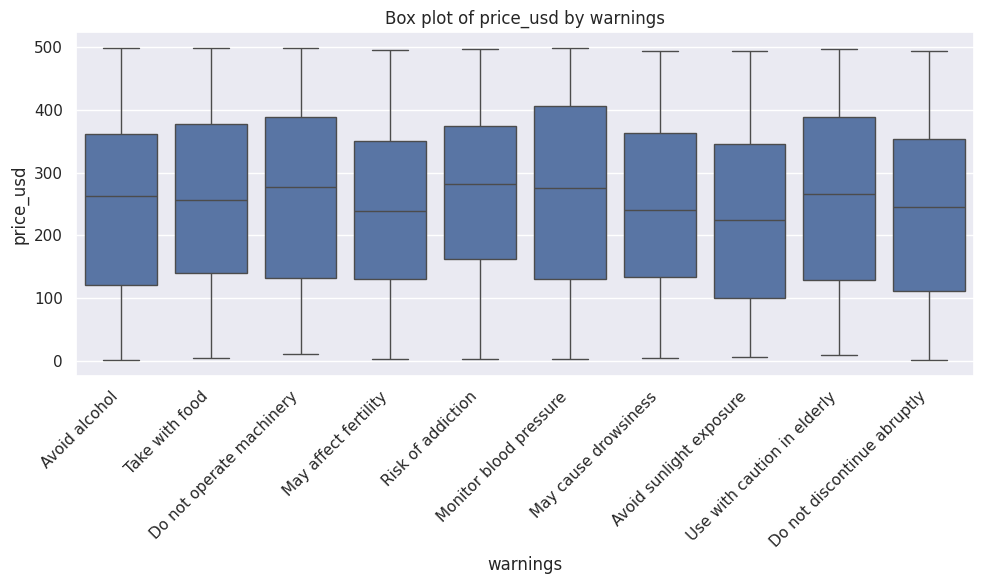

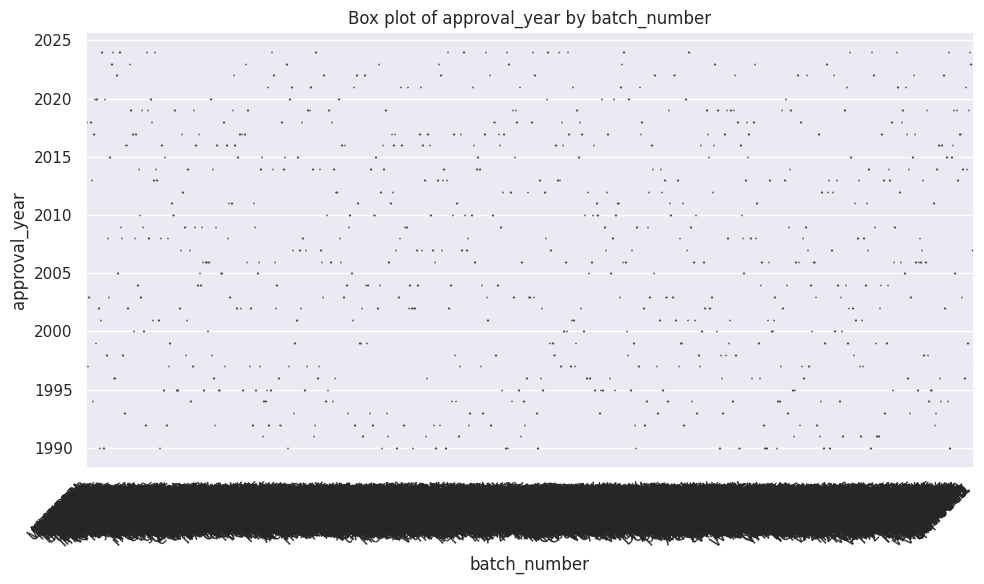

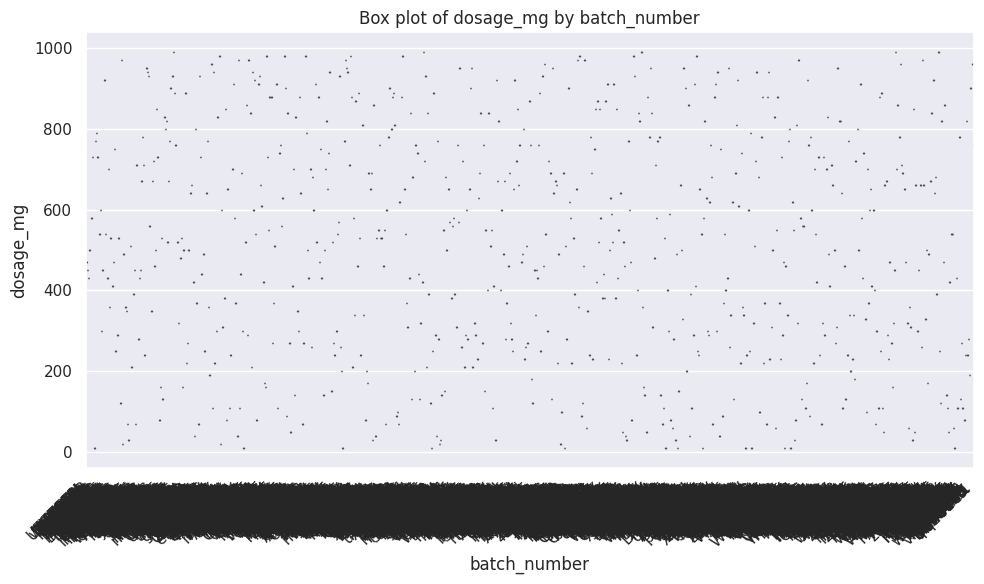

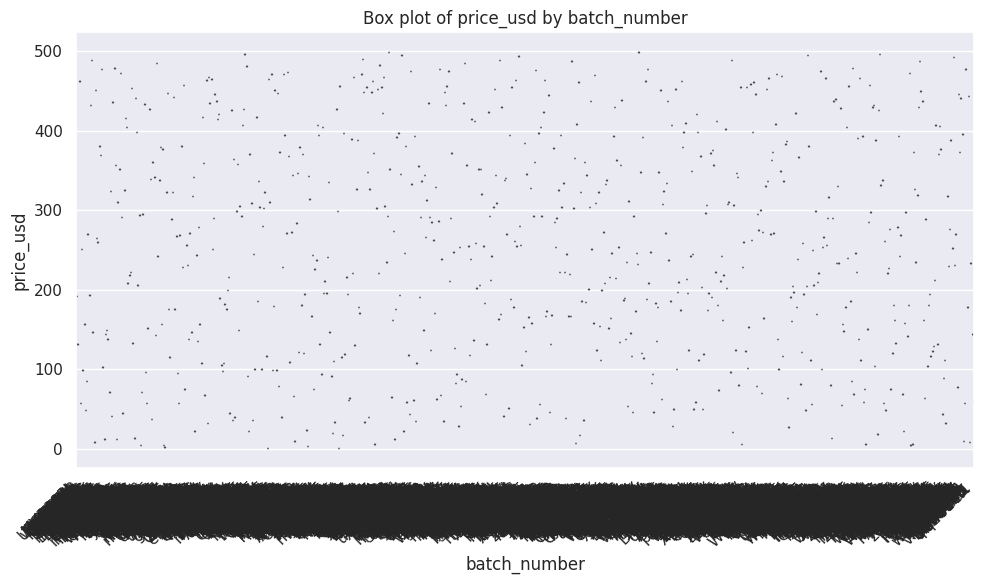

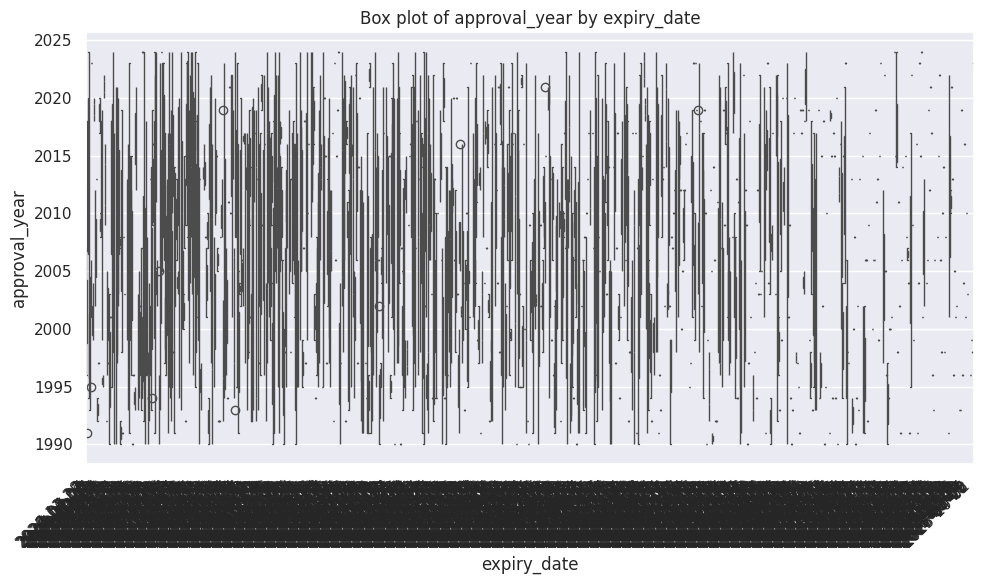

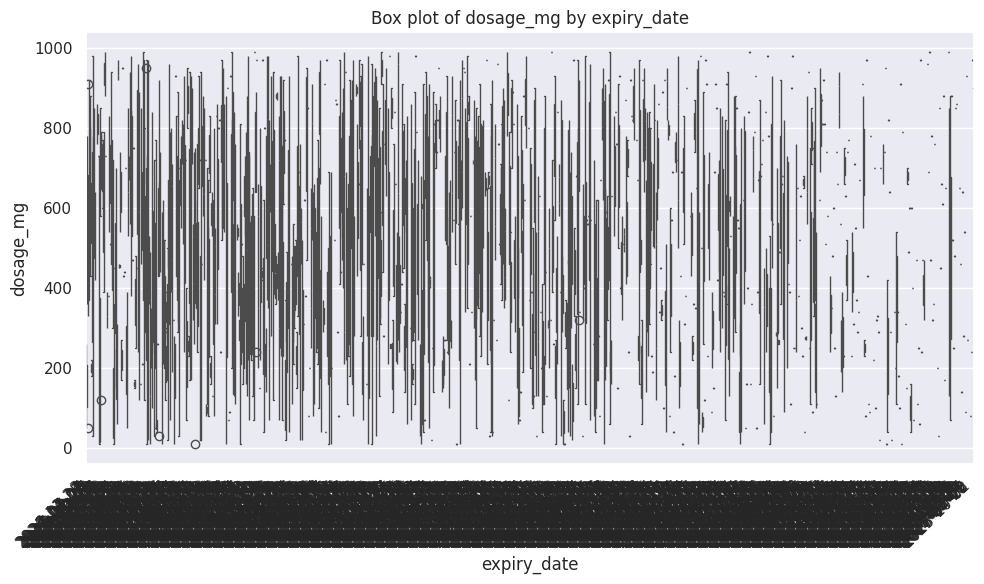

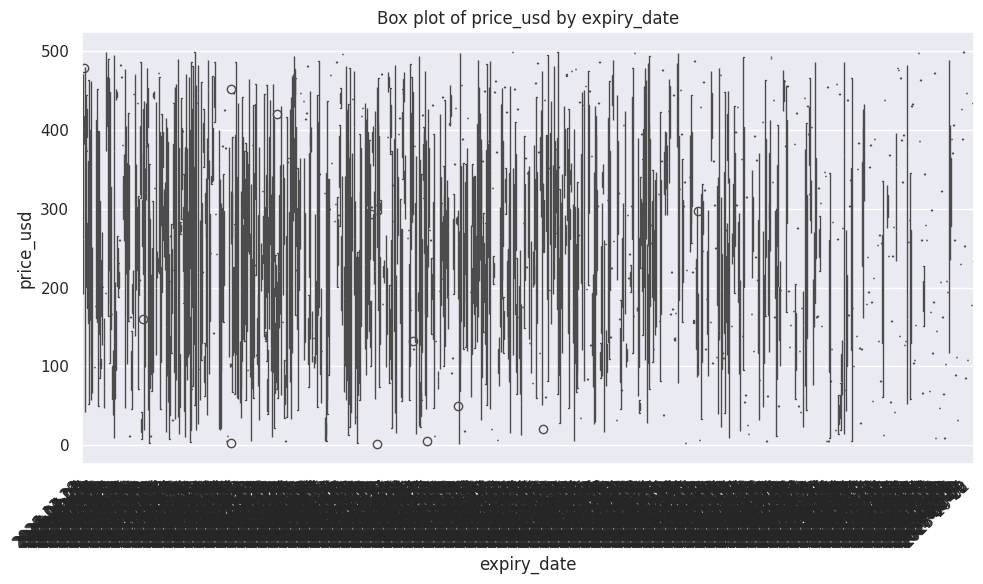

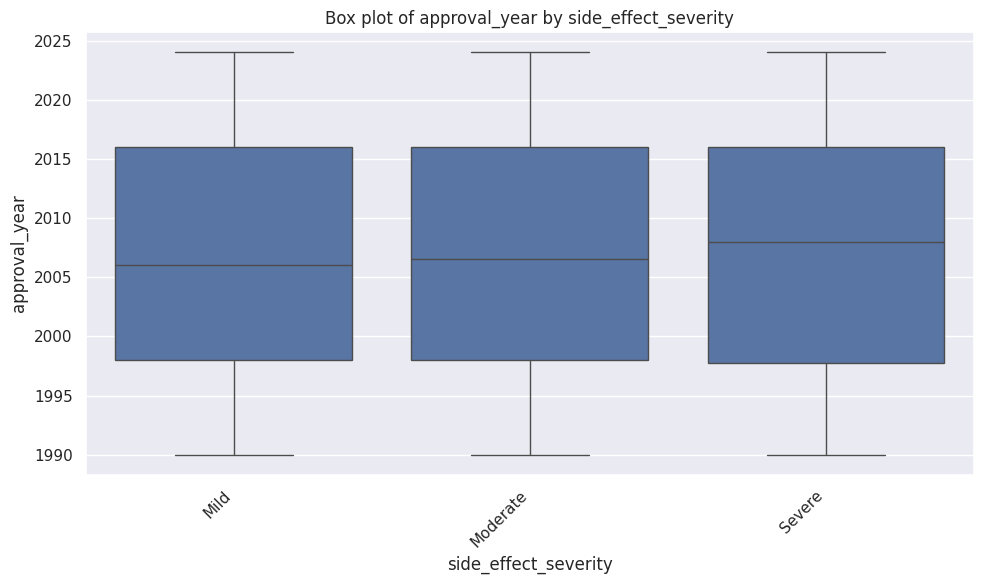

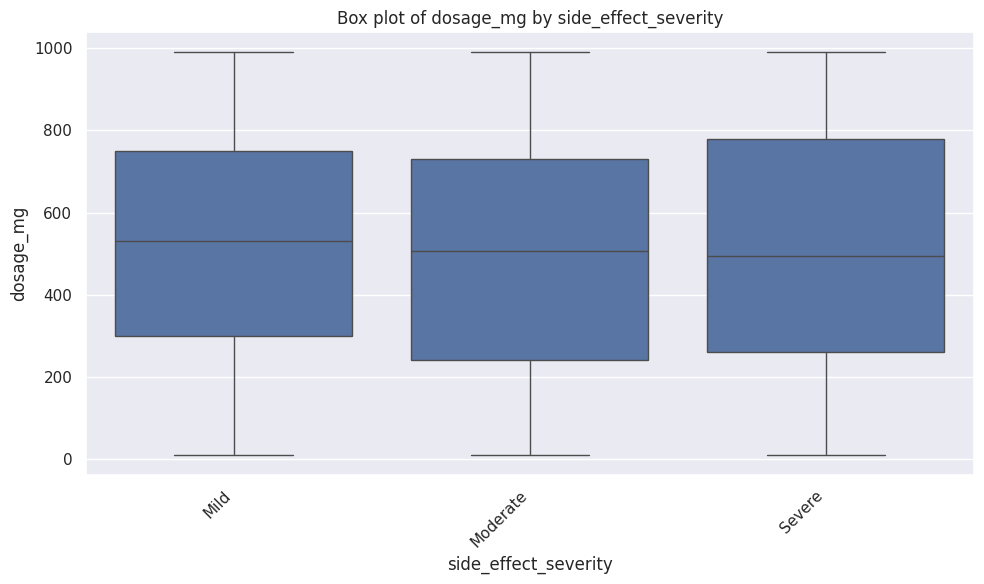

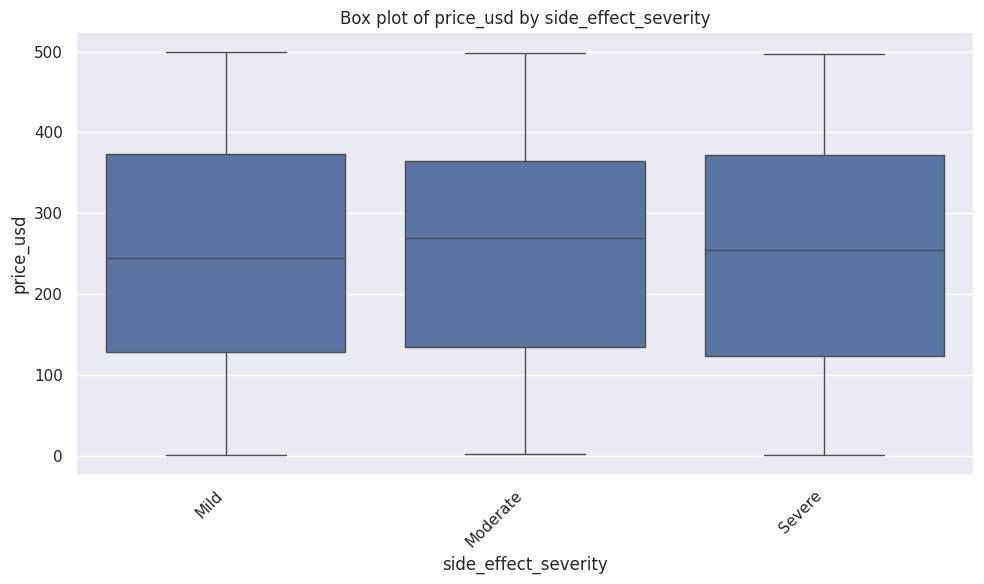

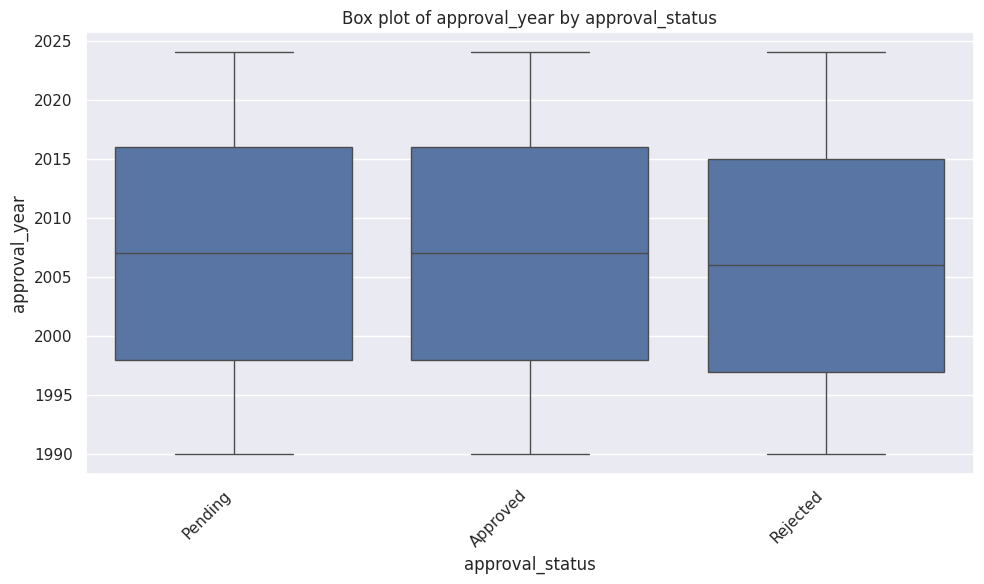

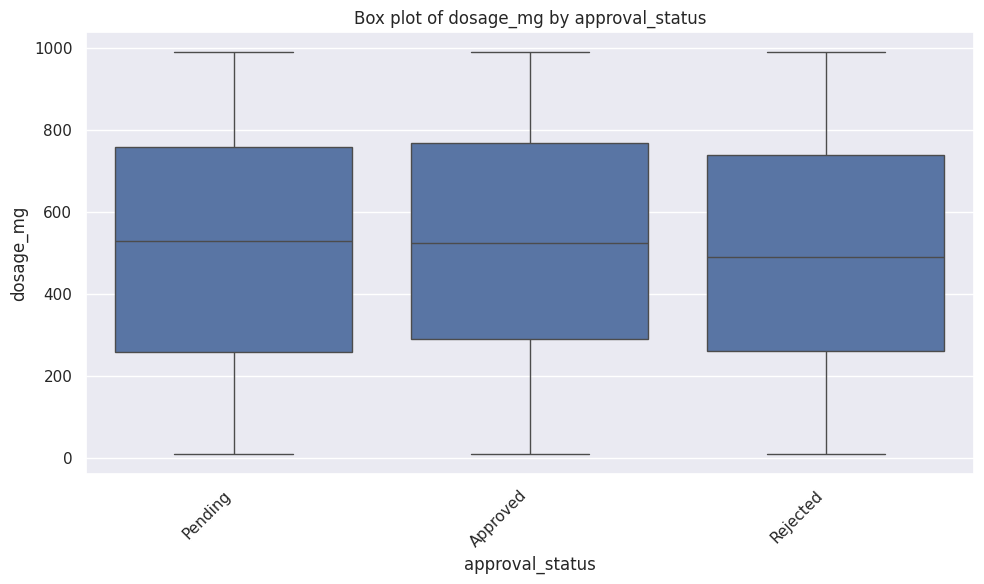

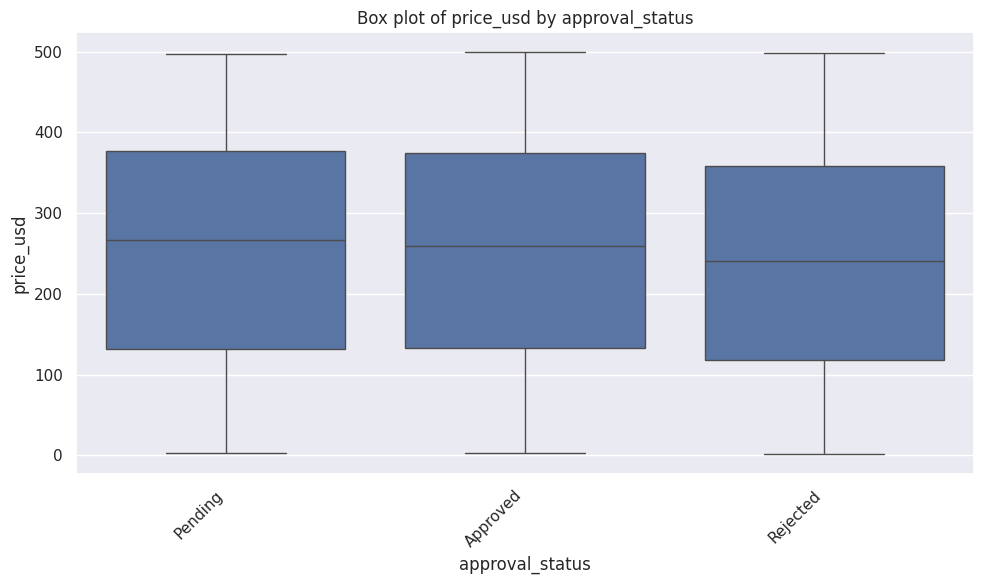

In [17]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Multivariate Analysis

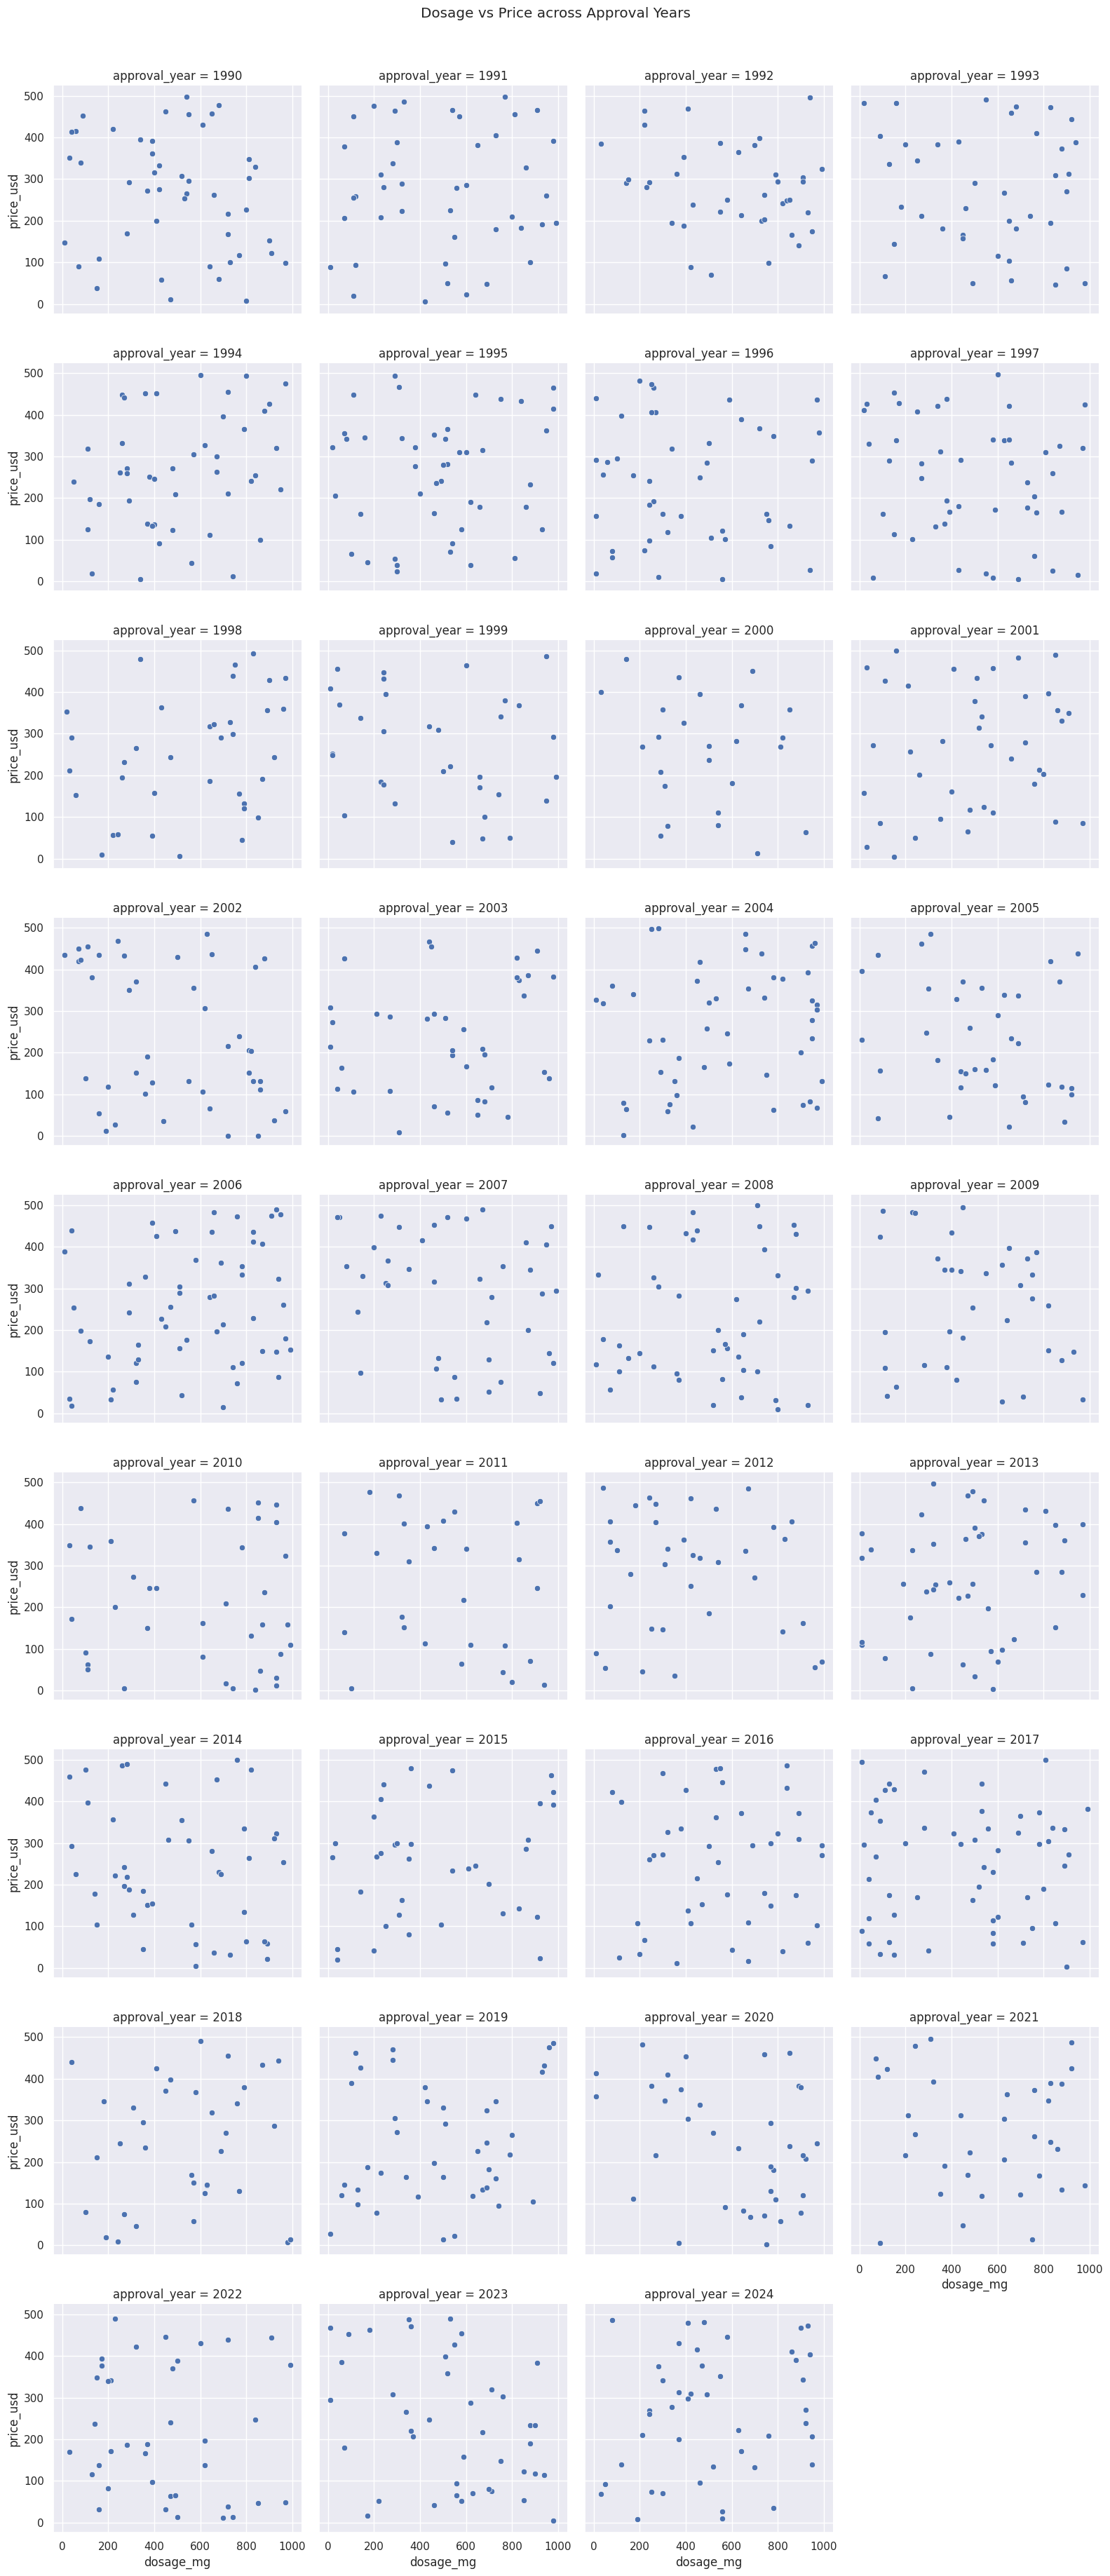

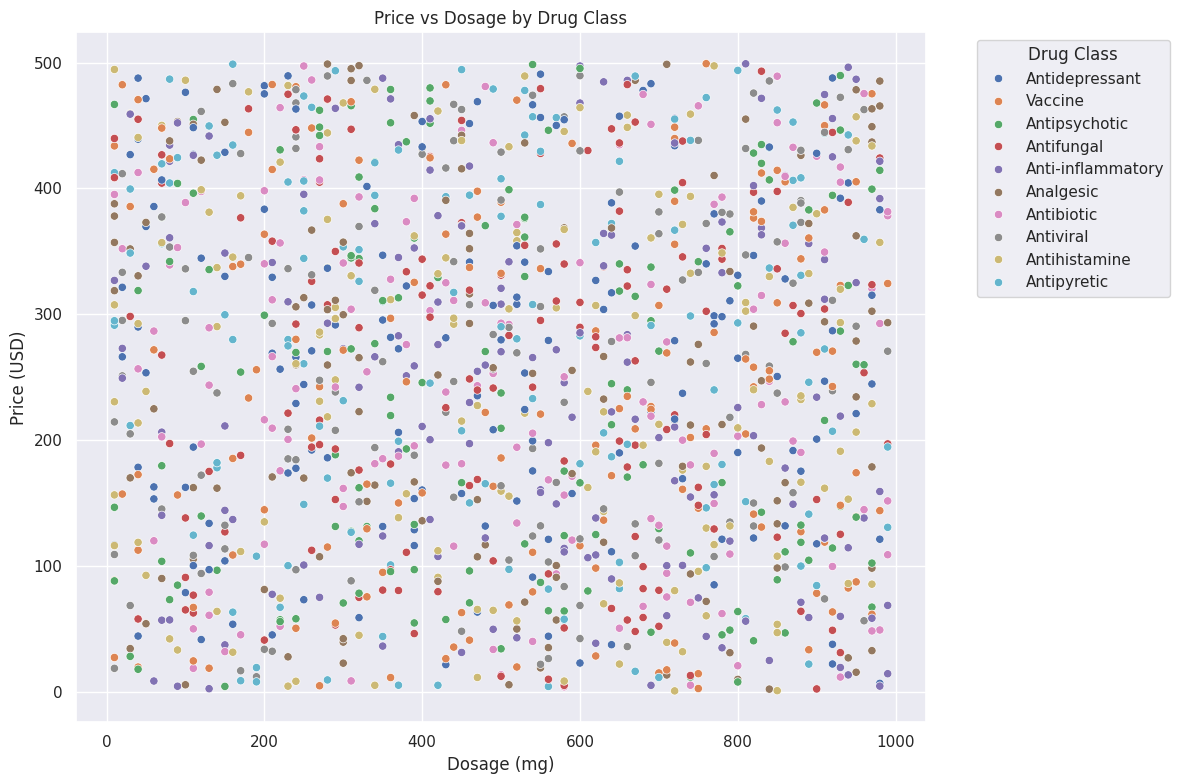

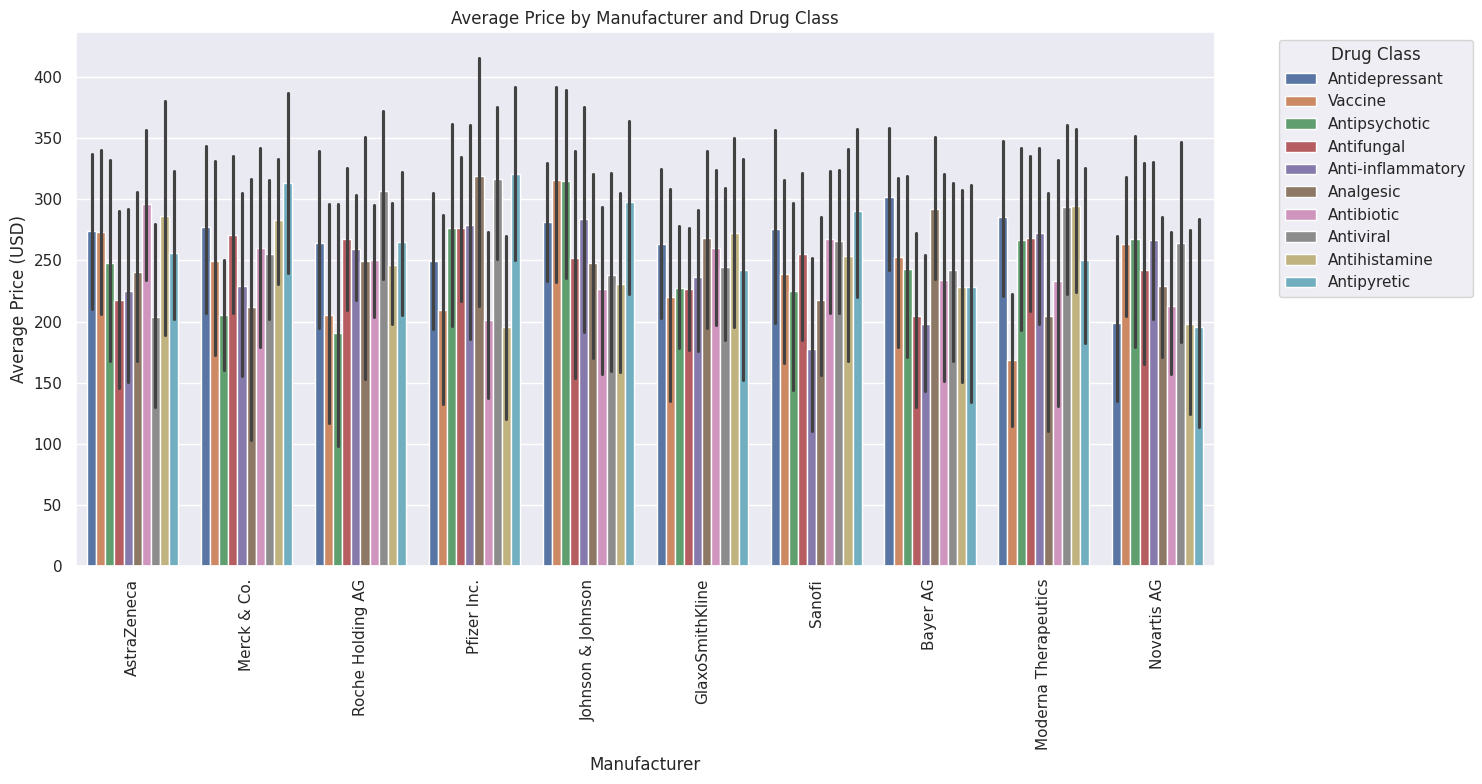

In [19]:
# Relationship between Range, Battery Capacity, and Year
g = sns.FacetGrid(df, col="approval_year", col_wrap=4, height=4)
g.map(sns.scatterplot, "dosage_mg", "price_usd")
plt.suptitle('Dosage vs Price across Approval Years', y=1.02)
plt.show()

# Relationship between Price, Range, and Battery Type
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="dosage_mg", y="price_usd", hue="drug_class")
plt.title('Price vs Dosage by Drug Class')
plt.xlabel('Dosage (mg)')
plt.ylabel('Price (USD)')
plt.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Exploring relationships between a numerical variable and two categorical variables
plt.figure(figsize=(15, 8))
sns.barplot(data=df, x="manufacturer", y="price_usd", hue="drug_class")
plt.title('Average Price by Manufacturer and Drug Class')
plt.xlabel('Manufacturer')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=90)
plt.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

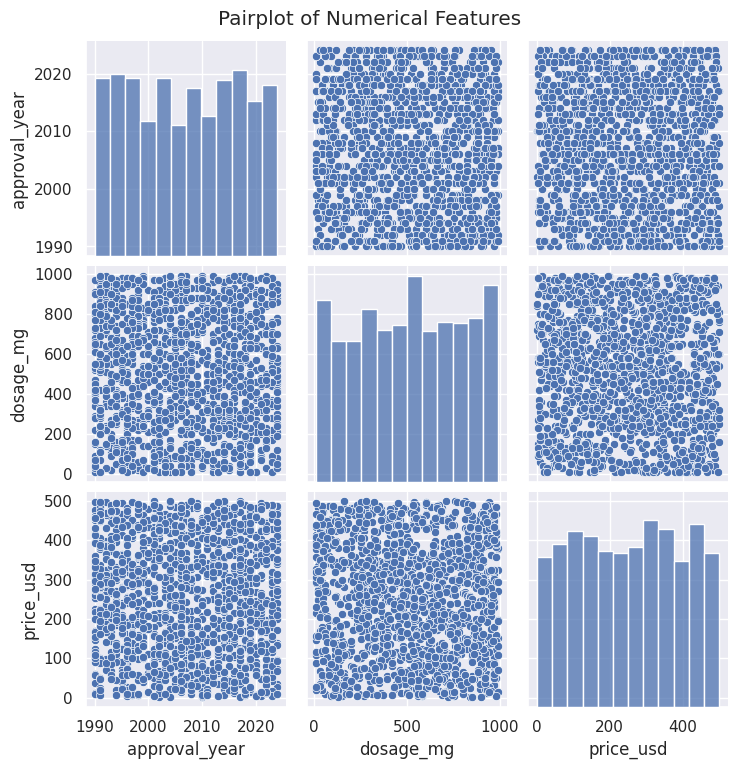

In [21]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

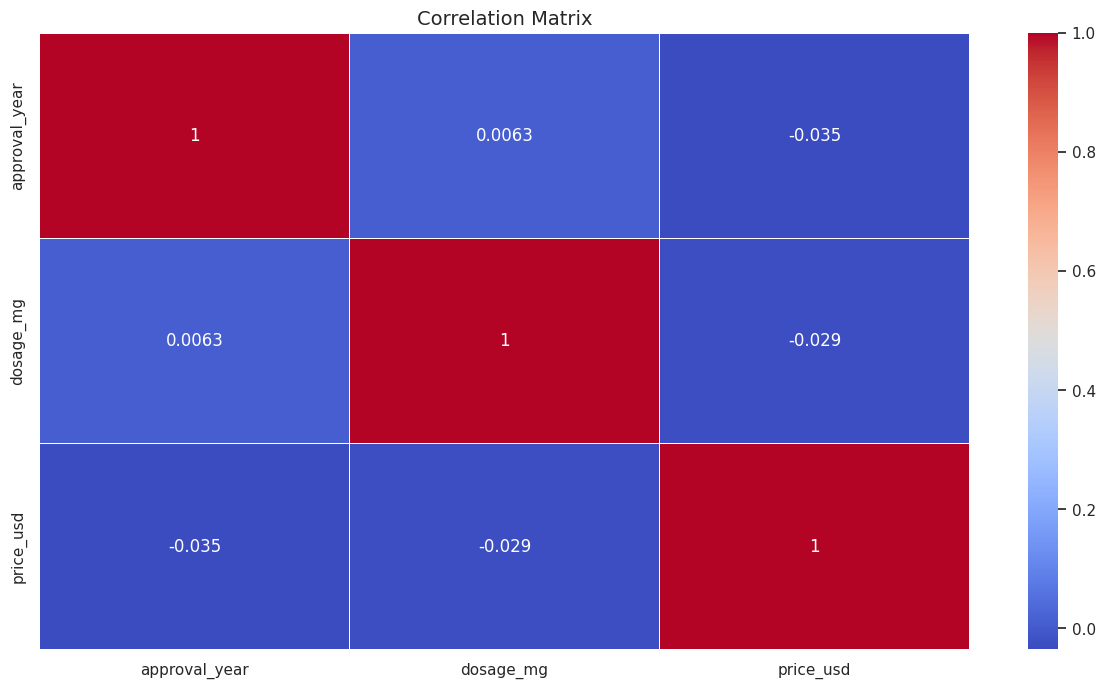

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you